# Binary classification tutorial: H -> ZZ -> 4 leptons

**Objective:** train an XGBoost binary classifier using two local CERN Open
Data ROOT files:

- Signal: `SMHiggsToZZTo4L.root`
- Background: `ZZTo2e2mu.root`

The files are assumed to contain a reduced NanoAOD-like `Events` TTree with
jagged Electron_* and Muon_* branches. We reconstruct the 2e2mu final state,
build physics-motivated event features, split the sample into independent
training/validation/test sets, train XGBoost with early stopping, and assess
its performance.


**Important scope note:** this is an educational classification tutorial,
not a publication-ready CMS analysis. It does not apply the full experiment
object IDs, trigger selections, scale factors, luminosity normalization,
systematic uncertainties, or official H -> ZZ -> 4l candidate algorithm.

See : https://opendata.cern.ch/record/12360 DOI:10.7483/OPENDATA.CMS.F7HD.P3K4


## 1. Install the required packages

Make sure that the following packages are installed :
```
uproot awkward vector pandas numpy matplotlib seaborn scikit-learn xgboost joblib
```

## 2. Imports and reproducibility

In [1]:
from pathlib import Path
import json
import warnings

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import uproot
import vector
import xgboost as xgb

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("uproot version: ", uproot.__version__)
print("awkward version:", ak.__version__)
print("xgboost version:", xgb.__version__)

uproot version:  5.6.9
awkward version: 2.8.12
xgboost version: 3.2.0


## 3. Configuration

Put this script/notebook in the same directory as the ROOT files, or change
the paths below.

`MASS_BLIND = False` includes the reconstructed four-lepton mass. This usually
gives strong separation because the signal has a resonance near 125 GeV while
continuum ZZ is broad. Set it to `True` to study classification without
giving the model the four-lepton mass directly.

In [2]:
import requests
from tqdm.notebook import tqdm
import os

url_S = "https://opendata.cern.ch/record/12361/files/SMHiggsToZZTo4L.root"
filename_S = "SMHiggsToZZTo4L.root"

url_B = "https://opendata.cern.ch/record/12364/files/ZZTo2e2mu.root"
filename_B = "ZZTo2e2mu.root"

filename = [filename_S, filename_B]
url = [url_S, url_B]

for i in range(2):
    if not os.path.exists(filename[i]):
        response = requests.get(url[i], stream=True)
        total = int(response.headers.get("content-length", 0))
        with open(filename[i], "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk)) 
        print(f"Downloaded {filename[i]}")
    else:
        print(f"{filename[i]} already exists")

SMHiggsToZZTo4L.root already exists
ZZTo2e2mu.root already exists


In [32]:
SIGNAL_FILE = Path("./SMHiggsToZZTo4L.root")
BACKGROUND_FILE = Path("./ZZTo2e2mu.root")
TREE_NAME = "Events"

MASS_BLIND = True
TEST_FRACTION = 0.20
VALIDATION_FRACTION_OF_REMAINDER = 0.25  # gives 60/20/20 overall

OUTPUT_MODEL = Path("higgs_xgboost_model.json")
OUTPUT_METADATA = Path("higgs_xgboost_metadata.json")
OUTPUT_PREDICTIONS = Path("higgs_xgboost_test_predictions.csv")

## 4. Inspect the files and validate the input schema

Uproot reads ROOT TTrees directly into NumPy/Awkward-compatible structures.
Before processing millions of values, we verify that the files, tree, and
required branches exist. If your reduced files use different branch names,
the error message will show what is missing.

In [33]:
REQUIRED_BRANCHES = [
    "nElectron",
    "Electron_pt",
    "Electron_eta",
    "Electron_phi",
    "Electron_mass",
    "Electron_charge",
    "nMuon",
    "Muon_pt",
    "Muon_eta",
    "Muon_phi",
    "Muon_mass",
    "Muon_charge",
    "MET_pt",
]


def validate_root_file(filename: Path, tree_name: str = TREE_NAME) -> None:
    """Check that a ROOT file contains the expected tree and branches."""
    if not filename.is_file():
        raise FileNotFoundError(
            f"Cannot find {filename.resolve()}. Put the ROOT file beside the "
            "notebook/script or update its path in the configuration cell."
        )

    with uproot.open(filename) as root_file:
        available_objects = set(root_file.keys(cycle=False))
        if tree_name not in available_objects:
            raise KeyError(
                f"Tree {tree_name!r} is absent from {filename}. "
                f"Available top-level objects: {sorted(available_objects)}"
            )

        tree = root_file[tree_name]
        available_branches = set(tree.keys())
        missing = sorted(set(REQUIRED_BRANCHES) - available_branches)
        if missing:
            raise KeyError(
                f"Missing branches in {filename}: {missing}\n"
                f"First available branches: {sorted(available_branches)[:40]}"
            )

        print(
            f"Validated {filename}: tree={tree_name!r}, "
            f"entries={tree.num_entries:,}, branches={len(available_branches):,}"
        )


validate_root_file(SIGNAL_FILE)
validate_root_file(BACKGROUND_FILE)

Validated SMHiggsToZZTo4L.root: tree='Events', entries=299,973, branches=32
Validated ZZTo2e2mu.root: tree='Events', entries=1,497,445, branches=32


## 5. Load the required branches

Awkward Array preserves the variable number of leptons per event. Loading only
the branches used below reduces memory consumption.

In [34]:
def load_raw_arrays(filename: Path, tree_name: str = TREE_NAME) -> ak.Array:
    """Load the selected branches as one Awkward record array."""
    with uproot.open(f"{filename}:{tree_name}") as tree:
        arrays = tree.arrays(REQUIRED_BRANCHES, library="ak")
    return arrays


sig_raw = load_raw_arrays(SIGNAL_FILE)
bkg_raw = load_raw_arrays(BACKGROUND_FILE)

print(f"Raw signal events:     {len(sig_raw):,}")
print(f"Raw background events: {len(bkg_raw):,}")

Raw signal events:     299,973
Raw background events: 1,497,445


## 6. Reconstruct the 2e2mu final state

For clarity, this tutorial selects events containing **exactly two electrons
and exactly two muons**, with opposite charge in each same-flavour pair. This
removes pairing ambiguity. A complete H -> ZZ -> 4l analysis would also handle
events with additional leptons and the 4e and 4mu channels using a dedicated
candidate-ranking procedure.

We sort each lepton collection by transverse momentum, construct Lorentz
vectors, combine the e+e- and mu+mu- pairs, and derive invariant masses and
angular/separation variables.

In [35]:
def make_p4(pt, eta, phi, mass):
    """Create an Awkward array of Lorentz momentum vectors."""
    return vector.zip({"pt": pt, "eta": eta, "phi": phi, "mass": mass})


def delta_phi(phi1, phi2):
    """Signed azimuthal separation wrapped to [-pi, pi)."""
    return (phi1 - phi2 + np.pi) % (2.0 * np.pi) - np.pi


def reconstruct_features(arr: ak.Array, sample_name: str) -> pd.DataFrame:
    """Select exactly 2e2mu opposite-sign events and build flat ML features."""
    # Exactly 2e2mu avoids ambiguous candidate pairing in this tutorial.
    multiplicity_mask = (arr.nElectron == 2) & (arr.nMuon == 2)
    selected = arr[multiplicity_mask]

    if len(selected) == 0:
        raise ValueError(f"No exactly-2e2mu events found in {sample_name}.")

    # Sort both flavours explicitly by descending pT. The same indices must be
    # applied to every property, including charge.
    e_order = ak.argsort(selected.Electron_pt, axis=1, ascending=False)
    m_order = ak.argsort(selected.Muon_pt, axis=1, ascending=False)

    e_pt = selected.Electron_pt[e_order]
    e_eta = selected.Electron_eta[e_order]
    e_phi = selected.Electron_phi[e_order]
    e_mass = selected.Electron_mass[e_order]
    e_charge = selected.Electron_charge[e_order]

    m_pt = selected.Muon_pt[m_order]
    m_eta = selected.Muon_eta[m_order]
    m_phi = selected.Muon_phi[m_order]
    m_mass = selected.Muon_mass[m_order]
    m_charge = selected.Muon_charge[m_order]

    # Both Z candidates must be same-flavour, opposite-sign pairs.
    charge_mask = (
        (e_charge[:, 0] * e_charge[:, 1] == -1)
        & (m_charge[:, 0] * m_charge[:, 1] == -1)
    )

    e_pt, e_eta, e_phi, e_mass = (
        x[charge_mask] for x in (e_pt, e_eta, e_phi, e_mass)
    )
    m_pt, m_eta, m_phi, m_mass = (
        x[charge_mask] for x in (m_pt, m_eta, m_phi, m_mass)
    )
    met_pt = selected.MET_pt[charge_mask]

    if len(e_pt) == 0:
        raise ValueError(
            f"No opposite-sign exactly-2e2mu events found in {sample_name}."
        )

    electrons = make_p4(e_pt, e_eta, e_phi, e_mass)
    muons = make_p4(m_pt, m_eta, m_phi, m_mass)

    z_ee = electrons[:, 0] + electrons[:, 1]
    z_mumu = muons[:, 0] + muons[:, 1]
    h4l = z_ee + z_mumu

    dphi_zz = delta_phi(z_ee.phi, z_mumu.phi)
    deta_zz = z_ee.eta - z_mumu.eta

    # Use absolute delta-phi and delta-eta values. Absolute angular differences
    # avoid giving the classifier an arbitrary detector rotation/orientation.
    features = {
        "H_mass": ak.to_numpy(h4l.mass),
        "H_pt": ak.to_numpy(h4l.pt),
        "abs_H_eta": np.abs(ak.to_numpy(h4l.eta)),
        "Zee_mass": ak.to_numpy(z_ee.mass),
        "Zmumu_mass": ak.to_numpy(z_mumu.mass),
        "Zee_pt": ak.to_numpy(z_ee.pt),
        "Zmumu_pt": ak.to_numpy(z_mumu.pt),
        "abs_delta_eta_ZZ": np.abs(ak.to_numpy(deta_zz)),
        "abs_delta_phi_ZZ": np.abs(ak.to_numpy(dphi_zz)),
        "deltaR_ZZ": np.hypot(
            ak.to_numpy(deta_zz), ak.to_numpy(dphi_zz)
        ),
        "electron1_pt": ak.to_numpy(electrons[:, 0].pt),
        "electron2_pt": ak.to_numpy(electrons[:, 1].pt),
        "muon1_pt": ak.to_numpy(muons[:, 0].pt),
        "muon2_pt": ak.to_numpy(muons[:, 1].pt),
        "abs_electron1_eta": np.abs(ak.to_numpy(electrons[:, 0].eta)),
        "abs_electron2_eta": np.abs(ak.to_numpy(electrons[:, 1].eta)),
        "abs_muon1_eta": np.abs(ak.to_numpy(muons[:, 0].eta)),
        "abs_muon2_eta": np.abs(ak.to_numpy(muons[:, 1].eta)),
        "MET_pt": ak.to_numpy(met_pt),
    }

    df = pd.DataFrame(features)
    df = df.replace([np.inf, -np.inf], np.nan)
    invalid = int(df.isna().any(axis=1).sum())
    if invalid:
        warnings.warn(f"Dropping {invalid} non-finite rows from {sample_name}.")
        df = df.dropna()

    print(
        f"{sample_name}: {len(arr):,} raw -> "
        f"{int(ak.sum(multiplicity_mask)):,} exactly 2e2mu -> "
        f"{len(df):,} opposite-sign finite events"
    )
    return df.reset_index(drop=True)


sig_df = reconstruct_features(sig_raw, "Signal")
bkg_df = reconstruct_features(bkg_raw, "Background")

Signal: 299,973 raw -> 30,868 exactly 2e2mu -> 27,496 opposite-sign finite events
Background: 1,497,445 raw -> 200,904 exactly 2e2mu -> 181,991 opposite-sign finite events


## 7. Label, combine, and inspect the dataset

In [36]:
sig_df["label"] = 1
bkg_df["label"] = 0

data = pd.concat([sig_df, bkg_df], ignore_index=True)
data = data.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

if MASS_BLIND:
    feature_names = [c for c in data.columns if c not in {"label", "H_mass"}]
else:
    feature_names = [c for c in data.columns if c != "label"]

X = data[feature_names].astype("float32")
y = data["label"].astype("int8")

if len(y.unique()) != 2:
    raise ValueError("Both signal and background are required for classification.")
if y.value_counts().min() < 10:
    raise ValueError("Too few selected events in at least one class.")
if not np.isfinite(X.to_numpy()).all():
    raise ValueError("The feature matrix still contains NaN or infinite values.")

print("\nSelected features:")
for name in feature_names:
    print(" -", name)
print("\nClass counts (0=background, 1=signal):")
print(y.value_counts().sort_index())
print("\nFeature summary:")
display(X.describe().T)


Selected features:
 - H_pt
 - abs_H_eta
 - Zee_mass
 - Zmumu_mass
 - Zee_pt
 - Zmumu_pt
 - abs_delta_eta_ZZ
 - abs_delta_phi_ZZ
 - deltaR_ZZ
 - electron1_pt
 - electron2_pt
 - muon1_pt
 - muon2_pt
 - abs_electron1_eta
 - abs_electron2_eta
 - abs_muon1_eta
 - abs_muon2_eta
 - MET_pt

Class counts (0=background, 1=signal):
label
0    181991
1     27496
Name: count, dtype: int64

Feature summary:


,count,mean,std,min,25%,50%,75%,max
H_pt,209487.0,29.393805,1485.451294,0.018666,7.903493,15.664331,31.665325,679704.750000
abs_H_eta,209487.0,2.496865,1.308078,0.000087,1.529377,2.469035,3.401765,9.085894
Zee_mass,209487.0,58.115204,36.996853,0.051527,22.880178,65.024338,89.230698,927.330933
Zmumu_mass,209487.0,48.024502,43.937019,0.000000,9.789813,39.613243,88.963215,8381.800781
Zee_pt,209487.0,36.323658,35.453621,0.031867,16.068785,26.264606,42.953360,898.711487
Zmumu_pt,209487.0,38.919064,1485.506592,0.029948,14.891777,25.094408,41.979311,679695.312500
abs_delta_eta_ZZ,209487.0,1.257228,1.051231,0.000007,0.468050,1.004850,1.758313,10.746816
abs_delta_phi_ZZ,209487.0,2.370882,0.836852,0.000003,2.012479,2.727849,2.996797,3.141592
deltaR_ZZ,209487.0,2.853998,0.928331,0.006588,2.469326,3.007768,3.276158,10.747637
electron1_pt,209487.0,42.369110,30.541704,5.012922,21.687468,37.439518,53.140068,648.444519


## 8. Exploratory distributions

These plots are unweighted and normalized to unit area, so they compare
shapes rather than expected event yields.

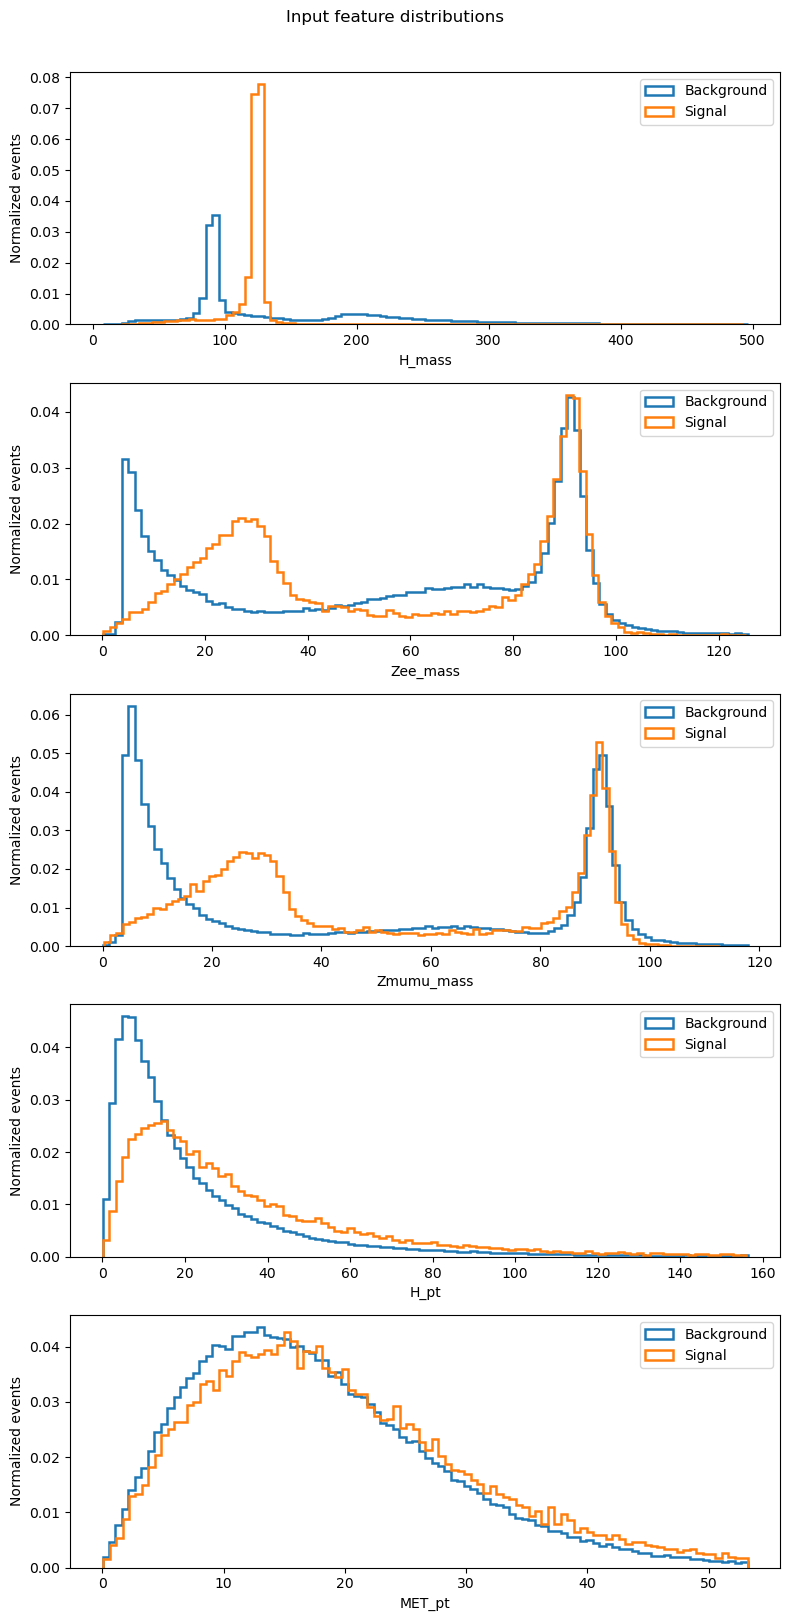

In [37]:
plot_features = ["H_mass", "Zee_mass", "Zmumu_mass", "H_pt", "MET_pt"]
plot_features = [f for f in plot_features if f in data.columns]

fig, axes = plt.subplots(
    nrows=len(plot_features), ncols=1, figsize=(8, 3.2 * len(plot_features))
)
if len(plot_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, plot_features):
    upper = data[feature].quantile(0.99)

    bg = data.loc[data.label == 0, feature]
    bg = bg[bg <= upper]

    sig = data.loc[data.label == 1, feature]
    sig = sig[sig <= upper]
    
    ax.hist(
        bg, bins=100, density=True,
        histtype="step", linewidth=1.8, label="Background"
    )
    ax.hist(
        sig, bins=100, density=True,
        histtype="step", linewidth=1.8, label="Signal"
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Normalized events")
    ax.legend()

fig.suptitle("Input feature distributions", y=1.01)
fig.tight_layout()
plt.show()

## 9. Independent train, validation, and test split

The validation set controls early stopping. The test set is not exposed to
training and is used only once for the final evaluation.

In [38]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=VALIDATION_FRACTION_OF_REMAINDER,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print(f"Training events:   {len(X_train):,}")
print(f"Validation events: {len(X_val):,}")
print(f"Test events:       {len(X_test):,}")

# Balanced event weights prevent the larger class from dominating the loss.
# They equalize total signal and background weight in the training sample.
train_weights = compute_sample_weight(class_weight="balanced", y=y_train)
val_weights = compute_sample_weight(class_weight="balanced", y=y_val)

Training events:   125,691
Validation events: 41,898
Test events:       41,898


## 10. Train XGBoost

`early_stopping_rounds` belongs in the estimator constructor in current
XGBoost versions. Training stops when validation log loss has not improved for
the requested number of boosting rounds.

In [39]:
model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2.0,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    sample_weight=train_weights,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[val_weights],
    verbose=False,
)

print("Best boosting iteration:", model.best_iteration)
print("Best validation score:  ", model.best_score)

Best boosting iteration: 1724
Best validation score:   0.23128180499354273


## 11. Learning curve

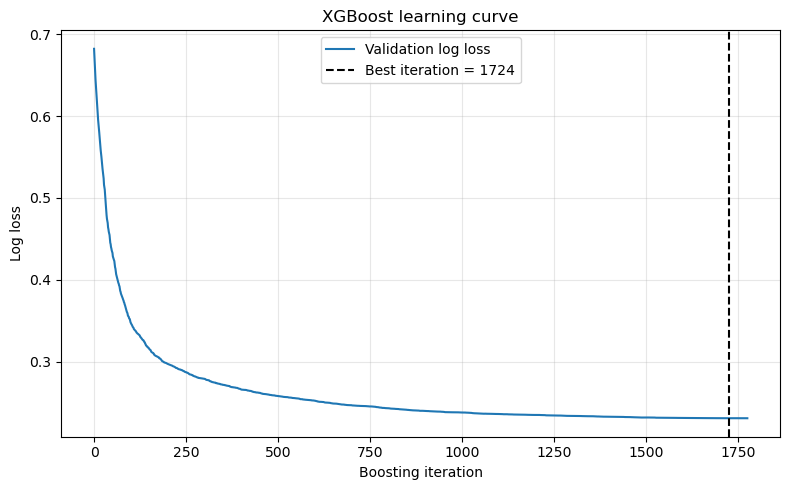

In [40]:
history = model.evals_result()
val_logloss = history["validation_0"]["logloss"]

plt.figure(figsize=(8, 5))
plt.plot(val_logloss, label="Validation log loss")
plt.axvline(
    model.best_iteration,
    color="black",
    linestyle="--",
    label=f"Best iteration = {model.best_iteration}",
)
plt.xlabel("Boosting iteration")
plt.ylabel("Log loss")
plt.title("XGBoost learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Final evaluation on the untouched test set

ROC AUC (Receiver Operating Characteristic - Area Under the Curve) is threshold-independent. 

Average precision summarizes the precision-recall curve and is useful when classes are imbalanced. 

Accuracy is also shown, but it should not be interpreted by itself.

In [41]:
y_score = model.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_score),
    "average_precision": average_precision_score(y_test, y_score),
}

for name, value in metrics.items():
    print(f"{name:>20s}: {value:.4f}")

print("\nClassification report at threshold 0.5:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Background", "Signal"],
        digits=4,
    )
)

            accuracy: 0.9100
   balanced_accuracy: 0.9153
             roc_auc: 0.9709
   average_precision: 0.8503

Classification report at threshold 0.5:

              precision    recall  f1-score   support

  Background     0.9873    0.9081    0.9460     36399
      Signal     0.6026    0.9225    0.7290      5499

    accuracy                         0.9100     41898
   macro avg     0.7949    0.9153    0.8375     41898
weighted avg     0.9368    0.9100    0.9175     41898



## 13. Confusion matrix

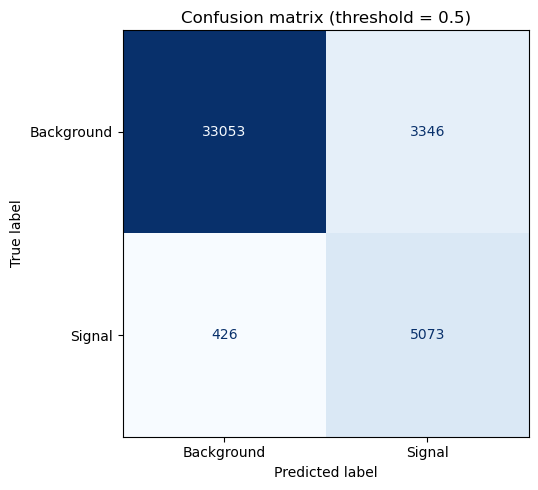

In [42]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Signal"],
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

## 14. ROC and precision-recall curves

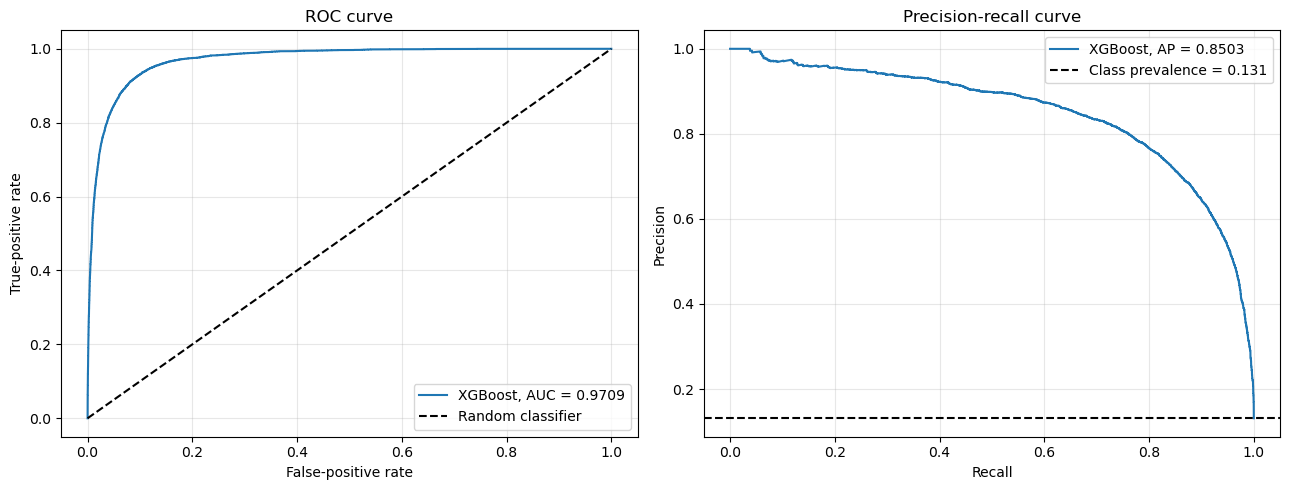

In [43]:
fpr, tpr, _ = roc_curve(y_test, y_score)
precision, recall, _ = precision_recall_curve(y_test, y_score)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"XGBoost, AUC = {metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].set_title("ROC curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

signal_fraction = float(y_test.mean())
axes[1].plot(
    recall,
    precision,
    label=f"XGBoost, AP = {metrics['average_precision']:.4f}",
)
axes[1].axhline(
    signal_fraction,
    color="black",
    linestyle="--",
    label=f"Class prevalence = {signal_fraction:.3f}",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 15. Classifier score distributions

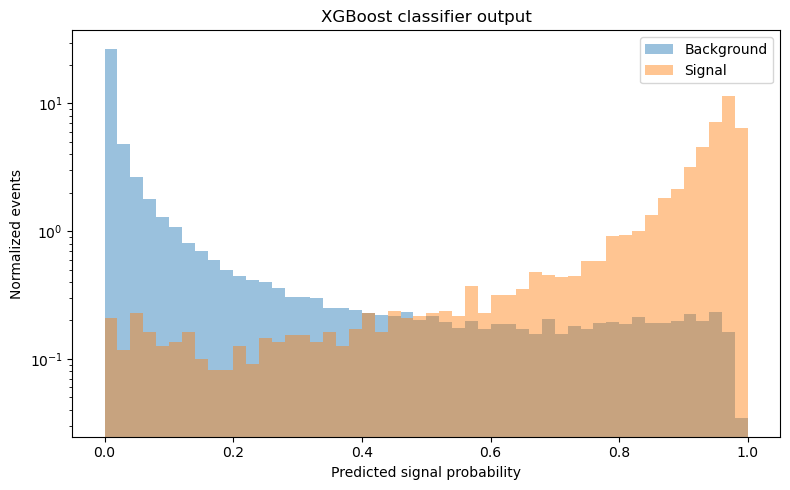

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(
    y_score[y_test.to_numpy() == 0],
    bins=50,
    range=(0, 1),
    density=True,
    histtype="stepfilled",
    alpha=0.45,
    label="Background",
)
plt.hist(
    y_score[y_test.to_numpy() == 1],
    bins=50,
    range=(0, 1),
    density=True,
    histtype="stepfilled",
    alpha=0.45,
    label="Signal",
)
plt.xlabel("Predicted signal probability")
plt.ylabel("Normalized events")
plt.title("XGBoost classifier output")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Feature importance

Built-in gain importance gives a quick overview, but it is not a causal
interpretation and correlated variables can share or distort importance.

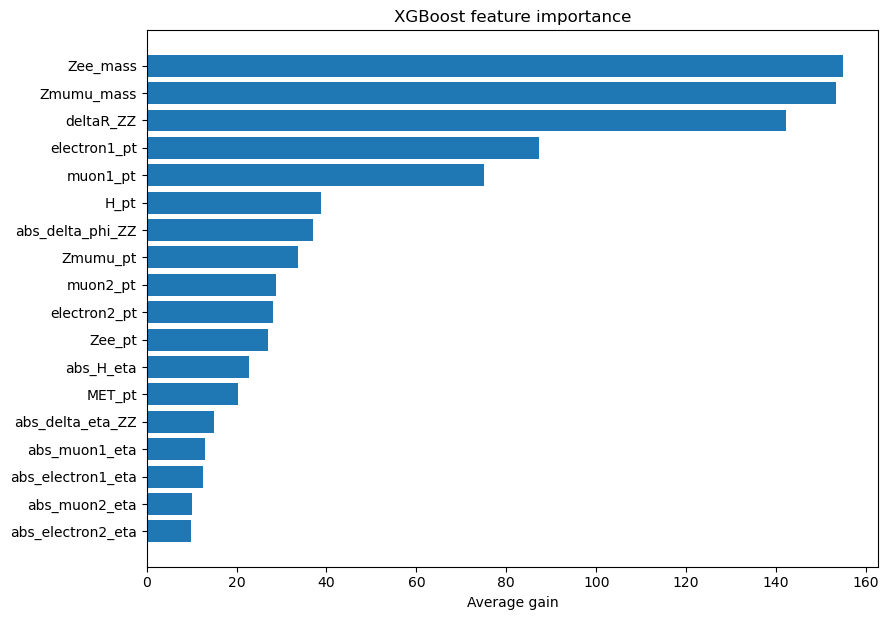

,feature,gain
0,Zee_mass,154.958405
1,Zmumu_mass,153.395325
2,deltaR_ZZ,142.134186
3,electron1_pt,87.257210
4,muon1_pt,75.056152
5,H_pt,38.757233
6,abs_delta_phi_ZZ,36.967918
7,Zmumu_pt,33.705215
8,muon2_pt,28.834400
9,electron2_pt,28.141151


In [45]:
booster = model.get_booster()
gain_map = booster.get_score(importance_type="gain")
importance = pd.DataFrame(
    {
        "feature": feature_names,
        "gain": [gain_map.get(name, 0.0) for name in feature_names],
    }
).sort_values("gain", ascending=True)

plt.figure(figsize=(9, max(5, 0.35 * len(importance))))
plt.barh(importance["feature"], importance["gain"])
plt.xlabel("Average gain")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()

display(importance.sort_values("gain", ascending=False).reset_index(drop=True))

## 17. Save the model, metadata, and test predictions

Save feature names and settings together with the model. A deployed model must
receive the same features in the same order and with the same reconstruction.

In [46]:
model.save_model(OUTPUT_MODEL)

metadata = {
    "signal_file": str(SIGNAL_FILE),
    "background_file": str(BACKGROUND_FILE),
    "tree_name": TREE_NAME,
    "mass_blind": MASS_BLIND,
    "feature_names": feature_names,
    "random_state": RANDOM_STATE,
    "best_iteration": int(model.best_iteration),
    "best_validation_score": float(model.best_score),
    "test_metrics": {k: float(v) for k, v in metrics.items()},
    "selection": "exactly 2 electrons and 2 muons; opposite-sign per flavour",
}
OUTPUT_METADATA.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

predictions = X_test.copy()
predictions["true_label"] = y_test.to_numpy()
predictions["signal_probability"] = y_score
predictions["predicted_label_at_0p5"] = y_pred
predictions.to_csv(OUTPUT_PREDICTIONS, index=False)

print(f"Saved model:       {OUTPUT_MODEL.resolve()}")
print(f"Saved metadata:    {OUTPUT_METADATA.resolve()}")
print(f"Saved predictions: {OUTPUT_PREDICTIONS.resolve()}")

Saved model:       /home/christophe/Workspace/CourseAI/Classifier_School/higgs_xgboost_model.json
Saved metadata:    /home/christophe/Workspace/CourseAI/Classifier_School/higgs_xgboost_metadata.json
Saved predictions: /home/christophe/Workspace/CourseAI/Classifier_School/higgs_xgboost_test_predictions.csv


## 18. Optional study: how much does the four-lepton mass contribute?

Repeat the notebook with `MASS_BLIND = True` and compare the test ROC AUC.
This is especially important if the classifier will later be used to study or
fit the four-lepton mass distribution: directly training on `H_mass` can
sculpt that distribution and make interpretation more difficult.

## Suggested extensions

- Add quality, identification, isolation, impact-parameter, and trigger cuts
  if those branches are available.
- Include 4e and 4mu final states with an unambiguous candidate algorithm.
- Use generator/event weights and cross sections for a yield-level study.
- Tune hyperparameters using cross-validation inside the training sample.
- Evaluate statistical uncertainty and check performance in physics-relevant
  control regions.
- Compare XGBoost with logistic regression, random forests, and neural nets.

## Invariant mass before and after the XGBoost selection

We determine the classifier threshold using the **validation sample**, not the
test sample. The selected threshold is then applied once to the untouched test
sample.

For this educational example, the threshold maximizes:

     S / sqrt(S + B)

 where S and B are the numbers of selected signal and background events in the
 validation sample.

 This is an unweighted pedagogical approximation. A physics analysis should use
 event weights, integrated luminosity, systematic uncertainties, and a more
 complete significance calculation.

In [20]:

def approximate_significance(signal_count, background_count):
    """
    Calculate the approximate counting significance S / sqrt(S + B).

    Parameters
    ----------
    signal_count : array-like
        Number of selected signal events.
    background_count : array-like
        Number of selected background events.

    Returns
    -------
    array-like
        Approximate significance.
    """
    denominator = np.sqrt(signal_count + background_count)

    return np.divide(
        signal_count,
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator > 0,
    )

In [62]:

# Obtain classifier scores for the validation sample.
validation_scores = model.predict_proba(X_val)[:, 1]

# Scan possible classifier thresholds.
thresholds = np.linspace(0.00, 0.99, 200)

validation_significances = []
validation_signal_efficiencies = []
validation_background_efficiencies = []

n_validation_signal = np.sum(y_val.to_numpy() == 1)
n_validation_background = np.sum(y_val.to_numpy() == 0)

for threshold in thresholds:
    selected = validation_scores >= threshold

    selected_signal = np.sum(
        selected & (y_val.to_numpy() == 1)
    )

    selected_background = np.sum(
        selected & (y_val.to_numpy() == 0)
    )

    significance = approximate_significance(
        np.asarray(selected_signal, dtype=float),
        np.asarray(selected_background, dtype=float),
    )

    signal_efficiency = selected_signal / n_validation_signal
    background_efficiency = selected_background / n_validation_background

    validation_significances.append(float(significance))
    validation_signal_efficiencies.append(signal_efficiency)
    validation_background_efficiencies.append(background_efficiency)

validation_significances = np.asarray(validation_significances)
validation_signal_efficiencies = np.asarray(validation_signal_efficiencies)
validation_background_efficiencies = np.asarray(
    validation_background_efficiencies
)

best_threshold_index = np.argmax(validation_significances)
optimal_threshold = thresholds[best_threshold_index]

print(f"Optimal validation threshold: {optimal_threshold:.3f}")
print(
    "Approximate validation significance at optimal threshold: ",
    f"{validation_significances[best_threshold_index]:.3f}"
)
print(
    "Validation signal efficiency: ",
    f"{validation_signal_efficiencies[best_threshold_index]:.3f}"
)
print(
    "Validation background efficiency: ",
    f"{validation_background_efficiencies[best_threshold_index]:.3f}"
)
print(
    "Validation background rejection: ",
    f"{1.0 - validation_background_efficiencies[best_threshold_index]:.3f}"
)

Optimal validation threshold: 0.771
Approximate validation significance at optimal threshold:  57.440
Validation signal efficiency:  0.807
Validation background efficiency:  0.042
Validation background rejection:  0.958


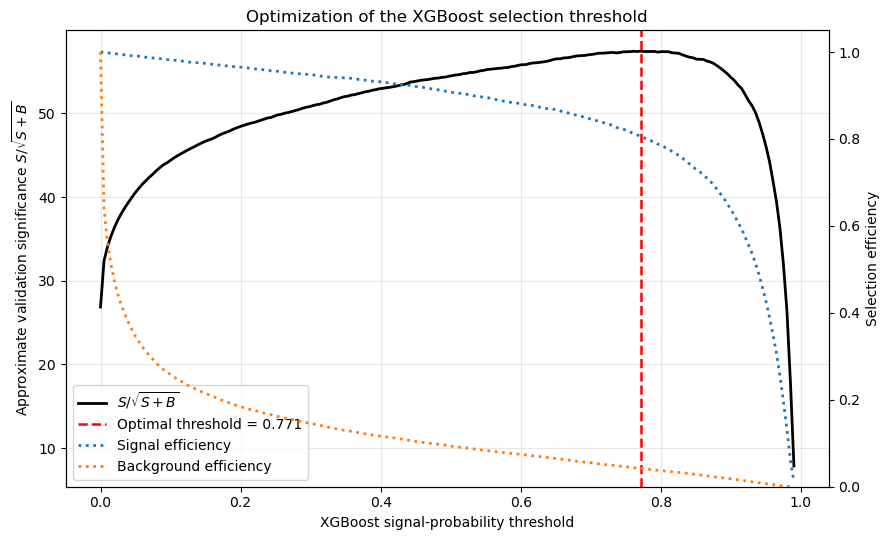

In [22]:

fig, ax1 = plt.subplots(figsize=(9, 5.5))

ax1.plot(
    thresholds,
    validation_significances,
    color="black",
    linewidth=2,
    label=r"$S/\sqrt{S+B}$",
)

ax1.axvline(
    optimal_threshold,
    color="red",
    linestyle="--",
    linewidth=1.8,
    label=f"Optimal threshold = {optimal_threshold:.3f}",
)

ax1.set_xlabel("XGBoost signal-probability threshold")
ax1.set_ylabel(r"Approximate validation significance $S/\sqrt{S+B}$")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    thresholds,
    validation_signal_efficiencies,
    color="tab:blue",
    linestyle=":",
    linewidth=2,
    label="Signal efficiency",
)

ax2.plot(
    thresholds,
    validation_background_efficiencies,
    color="tab:orange",
    linestyle=":",
    linewidth=2,
    label="Background efficiency",
)

ax2.set_ylabel("Selection efficiency")
ax2.set_ylim(0, 1.05)

# Combine legends from both axes.
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="best",
)

plt.title("Optimization of the XGBoost selection threshold")
fig.tight_layout()
plt.show()

 ### Apply the optimized threshold to the untouched test sample

 The threshold was selected using validation data. We now apply it to test data
 and compare the four-lepton invariant-mass distribution before and after the
 classifier selection.

In [23]:

# Retrieve the four-lepton mass from the original combined DataFrame.
# This works even if H_mass was excluded from the model features.
test_mass = data.loc[X_test.index, "H_mass"].to_numpy()

test_labels = y_test.to_numpy()
test_scores = model.predict_proba(X_test)[:, 1]

test_selection = test_scores >= optimal_threshold

# Before the XGBoost selection.
signal_mass_before = test_mass[test_labels == 1]
background_mass_before = test_mass[test_labels == 0]

# After the XGBoost selection.
signal_mass_after = test_mass[
    (test_labels == 1) & test_selection
]

background_mass_after = test_mass[
    (test_labels == 0) & test_selection
]

print("Test events before selection")
print(f"  Signal:     {len(signal_mass_before):,}")
print(f"  Background: {len(background_mass_before):,}")

print("\nTest events after selection")
print(f"  Signal:     {len(signal_mass_after):,}")
print(f"  Background: {len(background_mass_after):,}")

signal_efficiency_test = (
    len(signal_mass_after) / len(signal_mass_before)
)

background_efficiency_test = (
    len(background_mass_after) / len(background_mass_before)
)

print("\nTest-set selection performance")
print(f"  Signal efficiency:      {signal_efficiency_test:.3f}")
print(f"  Background efficiency:  {background_efficiency_test:.3f}")
print(f"  Background rejection:   {1.0 - background_efficiency_test:.3f}")

Test events before selection
  Signal:     5,499
  Background: 36,399

Test events after selection
  Signal:     4,524
  Background: 1,535

Test-set selection performance
  Signal efficiency:      0.823
  Background efficiency:  0.042
  Background rejection:   0.958


### Mass spectra before and after the application of the model 

We have the from the dataset the invariant mass of 4 leptons when it comes from the signal or from the background. The classification from the model can help to reject the background contribution while keeping the signal.

Let see the effect of the model classification and selection


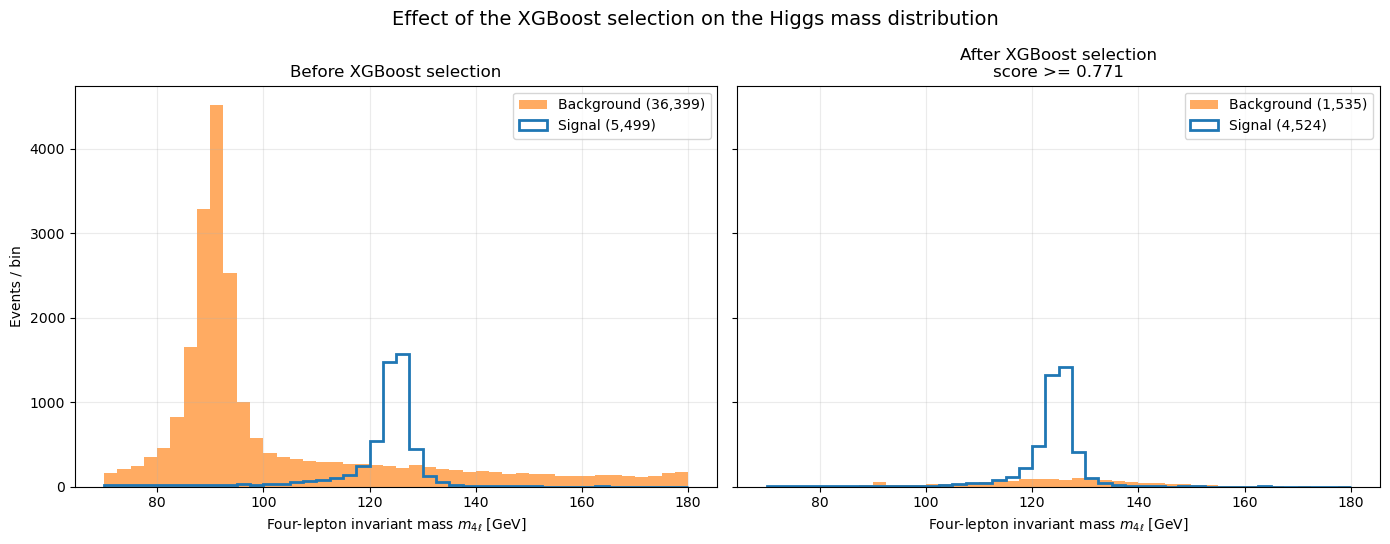

In [24]:

# Adjust this range if your samples cover a different mass region.
MASS_RANGE = (70, 180)
N_MASS_BINS = 44

mass_bins = np.linspace(
    MASS_RANGE[0],
    MASS_RANGE[1],
    N_MASS_BINS + 1,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5.5),
    sharex=True,
    sharey=True,
)

# ------------------------------------------------------------------
# Before selection
# ------------------------------------------------------------------
axes[0].hist(
    background_mass_before,
    bins=mass_bins,
    histtype="stepfilled",
    color="tab:orange",
    alpha=0.65,
    label=f"Background ({len(background_mass_before):,})",
)

axes[0].hist(
    signal_mass_before,
    bins=mass_bins,
    histtype="step",
    color="tab:blue",
    linewidth=2.0,
    label=f"Signal ({len(signal_mass_before):,})",
)

axes[0].set_title("Before XGBoost selection")
axes[0].set_xlabel(r"Four-lepton invariant mass $m_{4\ell}$ [GeV]")
axes[0].set_ylabel("Events / bin")
axes[0].legend()
axes[0].grid(alpha=0.25)

# ------------------------------------------------------------------
# After selection
# ------------------------------------------------------------------
axes[1].hist(
    background_mass_after,
    bins=mass_bins,
    histtype="stepfilled",
    color="tab:orange",
    alpha=0.65,
    label=f"Background ({len(background_mass_after):,})",
)

axes[1].hist(
    signal_mass_after,
    bins=mass_bins,
    histtype="step",
    color="tab:blue",
    linewidth=2.0,
    label=f"Signal ({len(signal_mass_after):,})",
)

axes[1].set_title(
    f"After XGBoost selection\n"
    f"score >= {optimal_threshold:.3f}"
)

axes[1].set_xlabel(r"Four-lepton invariant mass $m_{4\ell}$ [GeV]")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle(
    "Effect of the XGBoost selection on the Higgs mass distribution",
    fontsize=14,
)

fig.tight_layout()
plt.show()

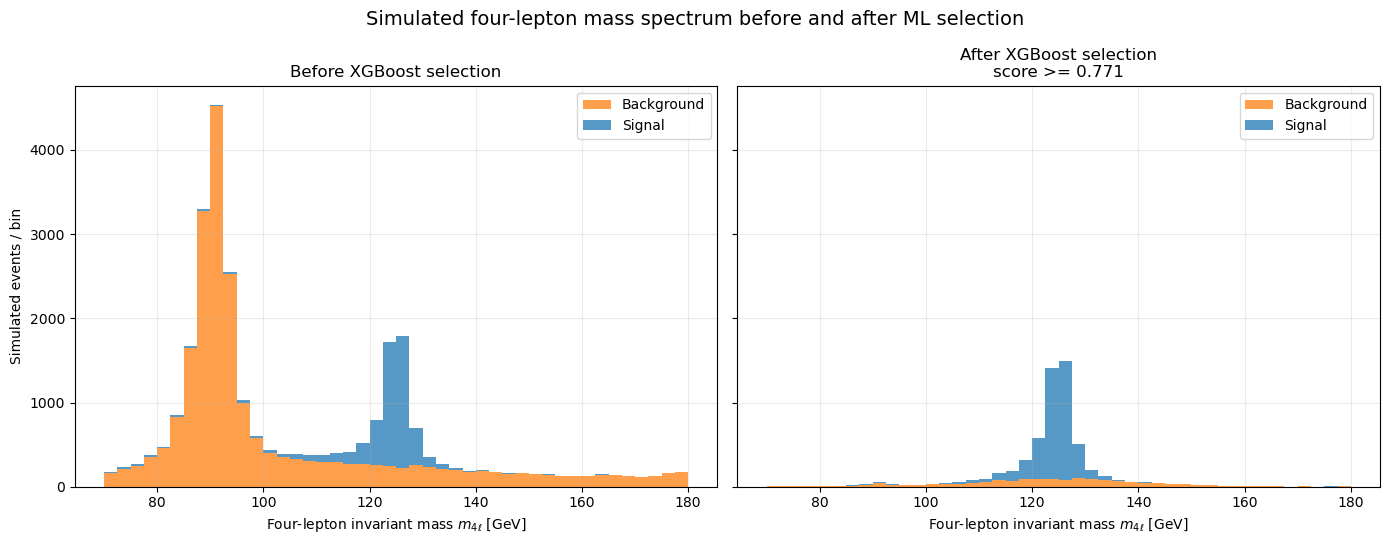

In [25]:

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5.5),
    sharex=True,
    sharey=True,
)

axes[0].hist(
    [background_mass_before, signal_mass_before],
    bins=mass_bins,
    stacked=True,
    color=["tab:orange", "tab:blue"],
    alpha=0.75,
    label=["Background", "Signal"],
)

axes[0].set_title("Before XGBoost selection")
axes[0].set_xlabel(r"Four-lepton invariant mass $m_{4\ell}$ [GeV]")
axes[0].set_ylabel("Simulated events / bin")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(
    [background_mass_after, signal_mass_after],
    bins=mass_bins,
    stacked=True,
    color=["tab:orange", "tab:blue"],
    alpha=0.75,
    label=["Background", "Signal"],
)

axes[1].set_title(
    f"After XGBoost selection\n"
    f"score >= {optimal_threshold:.3f}"
)

axes[1].set_xlabel(r"Four-lepton invariant mass $m_{4\ell}$ [GeV]")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle(
    "Simulated four-lepton mass spectrum before and after ML selection",
    fontsize=14,
)

fig.tight_layout()
plt.show()

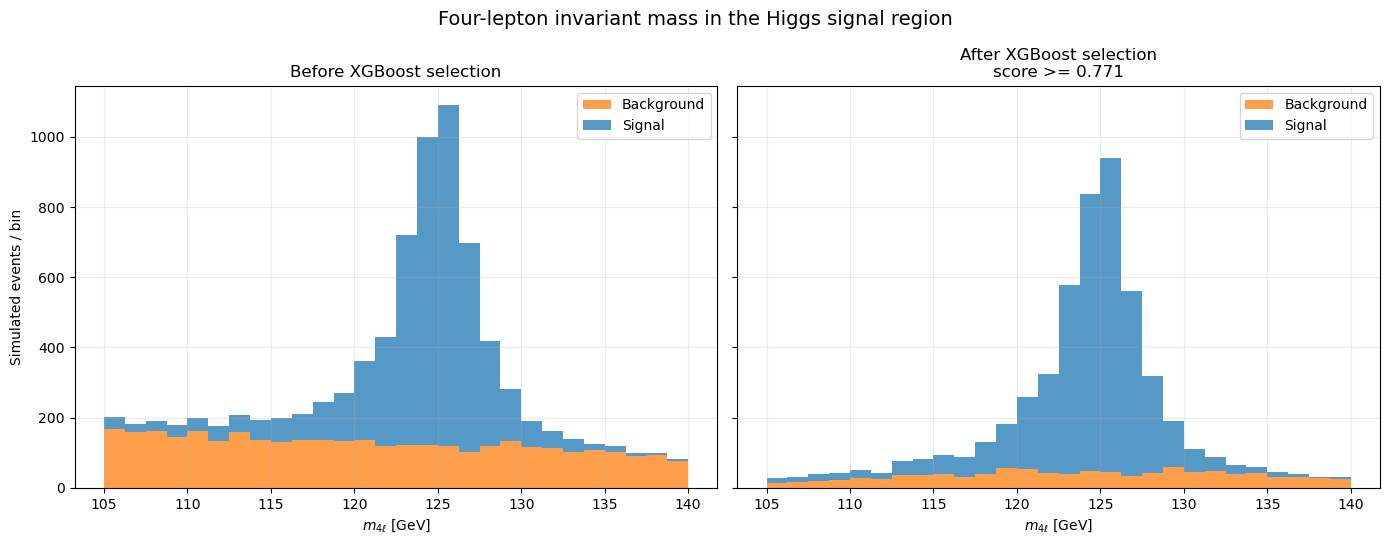

In [26]:

ZOOMED_MASS_RANGE = (105, 140)
ZOOMED_BINS = np.linspace(
    ZOOMED_MASS_RANGE[0],
    ZOOMED_MASS_RANGE[1],
    29,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5.5),
    sharex=True,
    sharey=True,
)

axes[0].hist(
    [background_mass_before, signal_mass_before],
    bins=ZOOMED_BINS,
    stacked=True,
    color=["tab:orange", "tab:blue"],
    alpha=0.75,
    label=["Background", "Signal"],
)

axes[0].set_title("Before XGBoost selection")
axes[0].set_xlabel(r"$m_{4\ell}$ [GeV]")
axes[0].set_ylabel("Simulated events / bin")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(
    [background_mass_after, signal_mass_after],
    bins=ZOOMED_BINS,
    stacked=True,
    color=["tab:orange", "tab:blue"],
    alpha=0.75,
    label=["Background", "Signal"],
)

axes[1].set_title(
    f"After XGBoost selection\n"
    f"score >= {optimal_threshold:.3f}"
)

axes[1].set_xlabel(r"$m_{4\ell}$ [GeV]")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle(
    "Four-lepton invariant mass in the Higgs signal region",
    fontsize=14,
)

fig.tight_layout()
plt.show()

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
    ),
])

baseline_model.fit(X_train, y_train)

baseline_scores = baseline_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_scores)

print(f"Logistic regression ROC AUC: {baseline_auc:.4f}")
print(f"XGBoost ROC AUC:             {metrics['roc_auc']:.4f}")

Logistic regression ROC AUC: 0.7827
XGBoost ROC AUC:             0.9709


### Model output for signal and background 

Let look at the model output for each class on each training and testing dataset

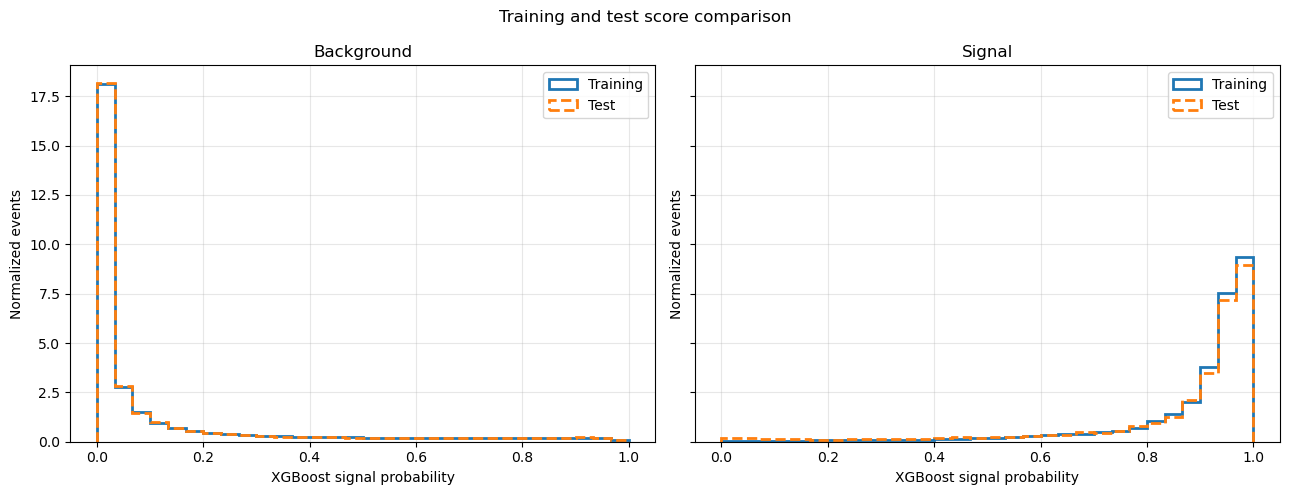

In [28]:
train_scores = model.predict_proba(X_train)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]

score_bins = np.linspace(0, 1, 31)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, class_label, class_name in zip(
    axes,
    [0, 1],
    ["Background", "Signal"],
):
    ax.hist(
        train_scores[y_train.to_numpy() == class_label],
        bins=score_bins,
        density=True,
        histtype="step",
        linewidth=2,
        label="Training",
    )

    ax.hist(
        test_scores[y_test.to_numpy() == class_label],
        bins=score_bins,
        density=True,
        histtype="step",
        linewidth=2,
        linestyle="--",
        label="Test",
    )

    ax.set_title(class_name)
    ax.set_xlabel("XGBoost signal probability")
    ax.set_ylabel("Normalized events")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Training and test score comparison")
fig.tight_layout()
plt.show()

### Signal efficiency versus background rejection

A signal efficiency vs. background rejection plot is a ROC (Receiver Operating Characteristic) curve with a mirrored x-axis !

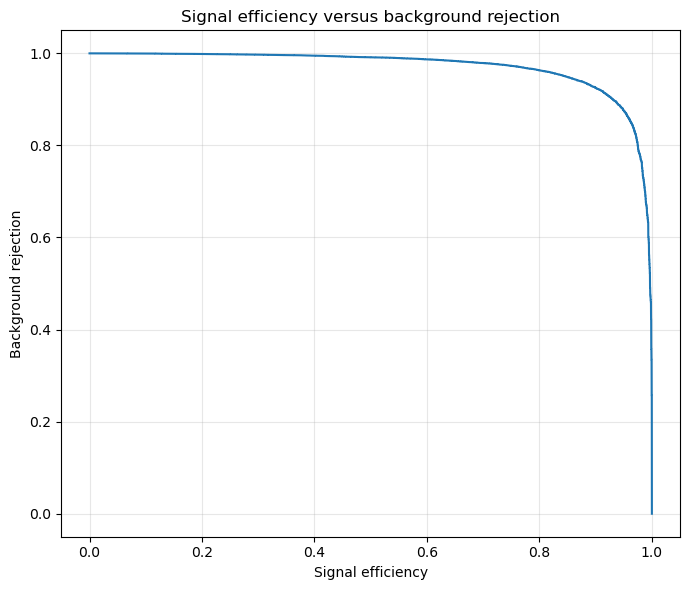

In [29]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_score)

signal_efficiency = tpr
background_rejection = 1.0 - fpr

plt.figure(figsize=(7, 6))
plt.plot(signal_efficiency, background_rejection)

plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection")
plt.title("Signal efficiency versus background rejection")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Permutation Importance

"How much does each feature actually contribute to the model predictions?"

* Permutation importance measures each feature's contribution by asking: "If I destroy this feature's information by shuffling it, how much worse does the model get?" 

* It's model-agnostic, works on any scoring metric, can be evaluated on held-out data, and gives a direct, intuitive measure of feature importance in the units of your chosen performance metric.

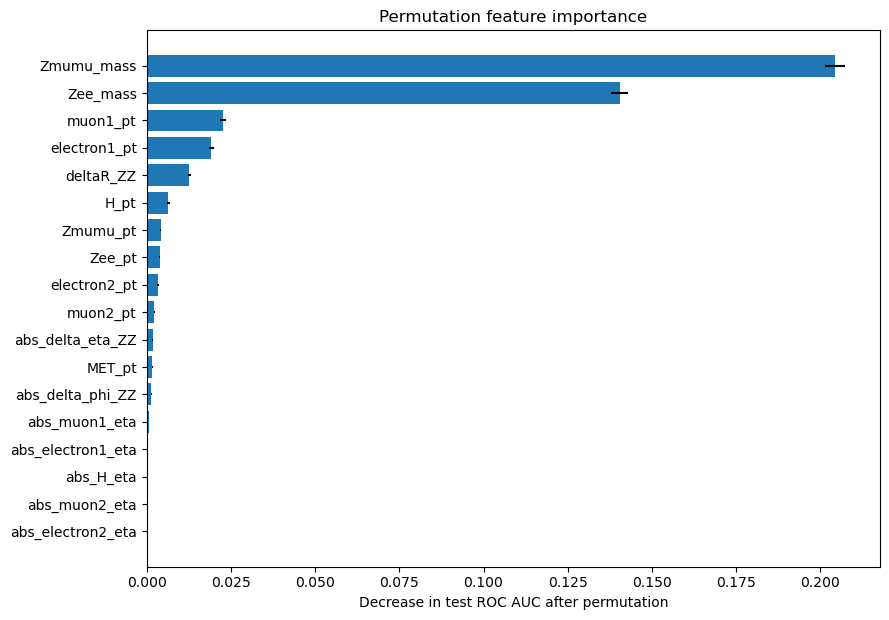

In [30]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
}).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(9, max(5, 0.35 * len(permutation_df))))

plt.barh(
    permutation_df["feature"],
    permutation_df["importance_mean"],
    xerr=permutation_df["importance_std"],
)

plt.xlabel("Decrease in test ROC AUC after permutation")
plt.title("Permutation feature importance")
plt.tight_layout()
plt.show()

### Probability calibration

* Probability calibration transforms a classifier's raw output scores into "honest", trustworthy probabilities : When the model says "70% chance" it really means roughly 7 out of 10 such cases are positive.

* CalibrationDisplay lets you visualize how well (or poorly) your model's probabilities match reality, and whether calibration methods like Platt scaling or isotonic regression can improve them.

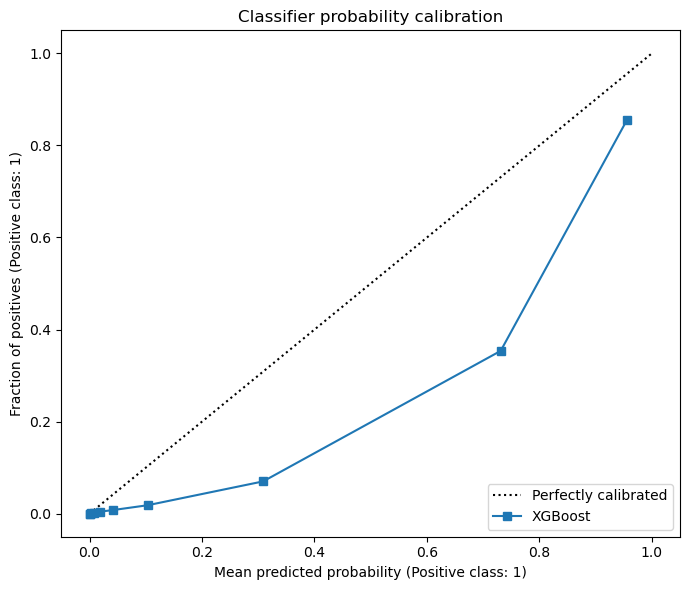

In [56]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_test,
    y_score,
    n_bins=10,
    strategy="quantile",
    ax=ax,
    name="XGBoost",
)

ax.set_title("Classifier probability calibration")
plt.tight_layout()
plt.show()

In [32]:
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_auc = []

y_test_array = y_test.to_numpy()

for _ in range(1000):
    indices = rng.integers(
        low=0,
        high=len(y_test_array),
        size=len(y_test_array),
    )

    sampled_labels = y_test_array[indices]
    sampled_scores = y_score[indices]

    # ROC AUC is undefined if a bootstrap sample contains one class.
    if np.unique(sampled_labels).size < 2:
        continue

    bootstrap_auc.append(
        roc_auc_score(sampled_labels, sampled_scores)
    )

lower, median, upper = np.percentile(
    bootstrap_auc,
    [2.5, 50, 97.5],
)

print(f"Median ROC AUC: {median:.4f}")
print(f"95% bootstrap interval: [{lower:.4f}, {upper:.4f}]")

Median ROC AUC: 0.9709
95% bootstrap interval: [0.9690, 0.9727]


In [33]:
summary = pd.Series({
    "Test ROC AUC": metrics["roc_auc"],
    "Optimal threshold": optimal_threshold,
    "Signal efficiency": signal_efficiency_test,
    "Background efficiency": background_efficiency_test,
    "Background rejection": 1.0 - background_efficiency_test,
})

display(summary.to_frame("Value"))

,Value
Test ROC AUC,0.970883
Optimal threshold,0.771106
Signal efficiency,0.822695
Background efficiency,0.042171
Background rejection,0.957829


In [34]:
features_mass_aware = [
    column for column in data.columns
    if column != "label"
]

features_mass_blind = [
    column for column in data.columns
    if column not in {"label", "H_mass"}
]

 ## NumPy neural-network baseline

 In this section, we implement a fully connected binary classifier using only
 NumPy. No neural-network framework such as TensorFlow, Keras, or PyTorch is
 used.

 Architecture:

     input features
          |
     dense + ReLU
          |
     dense + ReLU
          |
     dense + sigmoid
          |
     signal probability

 The network is trained using:

 - Binary cross-entropy loss
 - L2 regularization
 - Mini-batches
 - The Adam optimizer
 - Early stopping on validation loss

In [35]:

# Convert pandas objects to NumPy arrays.
X_train_nn = X_train.to_numpy(dtype=np.float64)
X_val_nn = X_val.to_numpy(dtype=np.float64)
X_test_nn = X_test.to_numpy(dtype=np.float64)

# Convert labels to column vectors with shape (number of events, 1).
y_train_nn = y_train.to_numpy(dtype=np.float64).reshape(-1, 1)
y_val_nn = y_val.to_numpy(dtype=np.float64).reshape(-1, 1)
y_test_nn = y_test.to_numpy(dtype=np.float64).reshape(-1, 1)

# Calculate standardization parameters using the training sample only.
feature_mean = X_train_nn.mean(axis=0, keepdims=True)
feature_std = X_train_nn.std(axis=0, keepdims=True)

# Protect against a feature with zero variance.
feature_std = np.where(feature_std < 1e-12, 1.0, feature_std)

# Apply exactly the same transformation to all three datasets.
X_train_nn = (X_train_nn - feature_mean) / feature_std
X_val_nn = (X_val_nn - feature_mean) / feature_std
X_test_nn = (X_test_nn - feature_mean) / feature_std

print("Training shape:  ", X_train_nn.shape)
print("Validation shape:", X_val_nn.shape)
print("Test shape:      ", X_test_nn.shape)

print("\nTraining feature means after standardization:")
print(np.round(X_train_nn.mean(axis=0), 3))

print("\nTraining feature standard deviations after standardization:")
print(np.round(X_train_nn.std(axis=0), 3))


Training shape:   (125691, 18)
Validation shape: (41898, 18)
Test shape:       (41898, 18)

Training feature means after standardization:
[ 0.  0.  0. -0.  0.  0. -0. -0. -0. -0. -0. -0. -0. -0. -0.  0.  0.  0.]

Training feature standard deviations after standardization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


 ### Activation and loss functions

 ReLU introduces nonlinearity in the hidden layers:

     ReLU(z) = max(0, z)

 The output layer uses a sigmoid to produce a number between zero and one:

     sigmoid(z) = 1 / (1 + exp(-z))

 Binary cross-entropy measures the agreement between the predicted signal
 probability and the true class label.

In [36]:

def relu(z):
    """Rectified linear-unit activation."""
    return np.maximum(0.0, z)


def relu_derivative(z):
    """Derivative of ReLU with respect to its input."""
    return (z > 0.0).astype(np.float64)


def sigmoid(z):
    """
    Numerically stable sigmoid activation.

    Clipping prevents overflow in exp for very large positive or negative
    values.
    """
    z = np.clip(z, -500.0, 500.0)
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y_true, y_probability):
    """Mean binary cross-entropy loss."""
    epsilon = 1e-12

    y_probability = np.clip(
        y_probability,
        epsilon,
        1.0 - epsilon,
    )

    return -np.mean(
        y_true * np.log(y_probability)
        + (1.0 - y_true) * np.log(1.0 - y_probability)
    )

 ### Neural-network class

 The class implements:

 - Parameter initialization
 - Forward propagation
 - Binary cross-entropy loss
 - Backpropagation
 - Adam parameter updates
 - Mini-batch training
 - Early stopping
 - Probability and class prediction

In [37]:
class NumPyBinaryClassifier:
    """
    Fully connected neural network for binary classification, implemented
    only with NumPy.

    Architecture
    ------------
    Input layer
        -> Dense hidden layer with ReLU
        -> Dense hidden layer with ReLU
        -> Dense output layer with sigmoid

    Training features
    -----------------
    - Binary cross-entropy loss
    - L2 weight regularization
    - He weight initialization
    - Mini-batch training
    - Adam optimization
    - Validation-based early stopping
    - Restoration of the best model parameters

    Notes
    -----
    The input features should be standardized before training.

    Labels are expected to have shape:

        (number_of_events, 1)

    and contain zeros for background and ones for signal.
    """

    def __init__(
        self,
        input_size,
        hidden_size_1=32,
        hidden_size_2=16,
        learning_rate=1e-3,
        l2_strength=1e-4,
        random_state=42,
    ):
        """
        Initialize the neural-network classifier.

        Parameters
        ----------
        input_size : int
            Number of input features.

        hidden_size_1 : int, default=32
            Number of neurons in the first hidden layer.

        hidden_size_2 : int, default=16
            Number of neurons in the second hidden layer.

        learning_rate : float, default=1e-3
            Learning rate used by the Adam optimizer.

        l2_strength : float, default=1e-4
            Strength of L2 weight regularization.

        random_state : int, default=42
            Seed used for reproducible initialization and shuffling.
        """
        self.input_size = int(input_size)
        self.hidden_size_1 = int(hidden_size_1)
        self.hidden_size_2 = int(hidden_size_2)

        self.learning_rate = float(learning_rate)
        self.l2_strength = float(l2_strength)
        self.random_state = int(random_state)

        if self.input_size <= 0:
            raise ValueError("input_size must be positive.")

        if self.hidden_size_1 <= 0 or self.hidden_size_2 <= 0:
            raise ValueError("Hidden-layer sizes must be positive.")

        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be positive.")

        if self.l2_strength < 0:
            raise ValueError("l2_strength cannot be negative.")

        self.rng = np.random.default_rng(self.random_state)

        self._initialize_parameters()
        self._initialize_adam()

        self.history = {
            "train_loss": [],
            "validation_loss": [],
            "train_accuracy": [],
            "validation_accuracy": [],
        }

        self.best_epoch = None
        self.best_validation_loss = None

    # ------------------------------------------------------------------
    # Activation functions
    # ------------------------------------------------------------------

    @staticmethod
    def _relu(values):
        """
        Apply the rectified linear-unit activation function.
        """
        return np.maximum(0.0, values)

    @staticmethod
    def _relu_derivative(values):
        """
        Calculate the derivative of ReLU with respect to its input.
        """
        return (values > 0.0).astype(np.float64)

    @staticmethod
    def _sigmoid(values):
        """
        Apply a numerically stable sigmoid activation function.
        """
        clipped_values = np.clip(values, -500.0, 500.0)

        return 1.0 / (
            1.0 + np.exp(-clipped_values)
        )

    @staticmethod
    def _binary_cross_entropy(
        true_labels,
        predicted_probabilities,
    ):
        """
        Calculate the mean binary cross-entropy loss.
        """
        epsilon = 1e-12

        probabilities = np.clip(
            predicted_probabilities,
            epsilon,
            1.0 - epsilon,
        )

        event_losses = -(
            true_labels * np.log(probabilities)
            + (1.0 - true_labels)
            * np.log(1.0 - probabilities)
        )

        return float(np.mean(event_losses))

    # ------------------------------------------------------------------
    # Parameter initialization
    # ------------------------------------------------------------------

    def _initialize_parameters(self):
        """
        Initialize network weights and biases.

        He initialization is used for the two ReLU hidden layers.
        The output-layer weights use a smaller variance.
        """
        first_layer_scale = np.sqrt(
            2.0 / self.input_size
        )

        self.W1 = self.rng.normal(
            loc=0.0,
            scale=first_layer_scale,
            size=(
                self.input_size,
                self.hidden_size_1,
            ),
        )

        self.b1 = np.zeros(
            (1, self.hidden_size_1),
            dtype=np.float64,
        )

        second_layer_scale = np.sqrt(
            2.0 / self.hidden_size_1
        )

        self.W2 = self.rng.normal(
            loc=0.0,
            scale=second_layer_scale,
            size=(
                self.hidden_size_1,
                self.hidden_size_2,
            ),
        )

        self.b2 = np.zeros(
            (1, self.hidden_size_2),
            dtype=np.float64,
        )

        output_layer_scale = np.sqrt(
            1.0 / self.hidden_size_2
        )

        self.W3 = self.rng.normal(
            loc=0.0,
            scale=output_layer_scale,
            size=(self.hidden_size_2, 1),
        )

        self.b3 = np.zeros(
            (1, 1),
            dtype=np.float64,
        )

    def _initialize_adam(self):
        """
        Initialize the first and second Adam moments.
        """
        parameter_names = [
            "W1",
            "b1",
            "W2",
            "b2",
            "W3",
            "b3",
        ]

        self.adam_m = {}
        self.adam_v = {}

        for parameter_name in parameter_names:
            parameter = getattr(
                self,
                parameter_name,
            )

            self.adam_m[parameter_name] = np.zeros_like(
                parameter
            )

            self.adam_v[parameter_name] = np.zeros_like(
                parameter
            )

        self.adam_step = 0

    # ------------------------------------------------------------------
    # Data validation
    # ------------------------------------------------------------------

    @staticmethod
    def _validate_inputs(features, labels=None):
        """
        Validate the dimensions and numerical content of input arrays.
        """
        features = np.asarray(
            features,
            dtype=np.float64,
        )

        if features.ndim != 2:
            raise ValueError(
                "Features must be a two-dimensional array."
            )

        if len(features) == 0:
            raise ValueError(
                "The feature array cannot be empty."
            )

        if not np.isfinite(features).all():
            raise ValueError(
                "Features contain NaN or infinite values."
            )

        if labels is None:
            return features

        labels = np.asarray(
            labels,
            dtype=np.float64,
        )

        if labels.ndim == 1:
            labels = labels.reshape(-1, 1)

        if labels.ndim != 2 or labels.shape[1] != 1:
            raise ValueError(
                "Labels must have shape (number_of_events, 1)."
            )

        if len(features) != len(labels):
            raise ValueError(
                "The feature and label arrays have different lengths."
            )

        if not np.isfinite(labels).all():
            raise ValueError(
                "Labels contain NaN or infinite values."
            )

        unique_labels = np.unique(labels)

        if not np.all(
            np.isin(unique_labels, [0.0, 1.0])
        ):
            raise ValueError(
                "Binary labels must contain only zero and one."
            )

        return features, labels

    # ------------------------------------------------------------------
    # Forward propagation
    # ------------------------------------------------------------------

    def forward(self, features):
        """
        Perform forward propagation.

        Parameters
        ----------
        features : ndarray
            Input array with shape:

                (number_of_events, number_of_features)

        Returns
        -------
        probabilities : ndarray
            Signal probabilities with shape:

                (number_of_events, 1)

        cache : dict
            Intermediate arrays required for backpropagation.
        """
        z1 = (
            features @ self.W1
            + self.b1
        )

        a1 = self._relu(z1)

        z2 = (
            a1 @ self.W2
            + self.b2
        )

        a2 = self._relu(z2)

        z3 = (
            a2 @ self.W3
            + self.b3
        )

        probabilities = self._sigmoid(z3)

        cache = {
            "features": features,
            "z1": z1,
            "a1": a1,
            "z2": z2,
            "a2": a2,
            "z3": z3,
            "probabilities": probabilities,
        }

        return probabilities, cache

    # ------------------------------------------------------------------
    # Loss
    # ------------------------------------------------------------------

    def _regularization_loss(
        self,
        number_of_events,
    ):
        """
        Calculate the L2 regularization penalty.

        Bias parameters are not regularized.
        """
        squared_weights = (
            np.sum(np.square(self.W1))
            + np.sum(np.square(self.W2))
            + np.sum(np.square(self.W3))
        )

        regularization_loss = (
            self.l2_strength
            * squared_weights
            / (2.0 * number_of_events)
        )

        return float(regularization_loss)

    def calculate_loss(
        self,
        features,
        labels,
        include_regularization=True,
    ):
        """
        Calculate binary cross-entropy and optional L2 regularization.
        """
        probabilities, _ = self.forward(features)

        loss = self._binary_cross_entropy(
            labels,
            probabilities,
        )

        if include_regularization:
            loss += self._regularization_loss(
                number_of_events=len(features)
            )

        return float(loss)

    # ------------------------------------------------------------------
    # Backpropagation
    # ------------------------------------------------------------------

    def backward(self, labels, cache):
        """
        Calculate parameter gradients using backpropagation.

        For a sigmoid output combined with binary cross-entropy,
        the output gradient simplifies to:

            predicted probability minus true label
        """
        features = cache["features"]
        z1 = cache["z1"]
        a1 = cache["a1"]
        z2 = cache["z2"]
        a2 = cache["a2"]
        probabilities = cache["probabilities"]

        batch_size = features.shape[0]

        # --------------------------------------------------------------
        # Output layer
        # --------------------------------------------------------------
        dz3 = probabilities - labels

        dW3 = (
            a2.T @ dz3
            + self.l2_strength * self.W3
        ) / batch_size

        db3 = (
            np.sum(
                dz3,
                axis=0,
                keepdims=True,
            )
            / batch_size
        )

        # --------------------------------------------------------------
        # Second hidden layer
        # --------------------------------------------------------------
        da2 = dz3 @ self.W3.T

        dz2 = (
            da2
            * self._relu_derivative(z2)
        )

        dW2 = (
            a1.T @ dz2
            + self.l2_strength * self.W2
        ) / batch_size

        db2 = (
            np.sum(
                dz2,
                axis=0,
                keepdims=True,
            )
            / batch_size
        )

        # --------------------------------------------------------------
        # First hidden layer
        # --------------------------------------------------------------
        da1 = dz2 @ self.W2.T

        dz1 = (
            da1
            * self._relu_derivative(z1)
        )

        dW1 = (
            features.T @ dz1
            + self.l2_strength * self.W1
        ) / batch_size

        db1 = (
            np.sum(
                dz1,
                axis=0,
                keepdims=True,
            )
            / batch_size
        )

        gradients = {
            "W1": dW1,
            "b1": db1,
            "W2": dW2,
            "b2": db2,
            "W3": dW3,
            "b3": db3,
        }

        return gradients

    # ------------------------------------------------------------------
    # Adam optimization
    # ------------------------------------------------------------------

    def _adam_update(
        self,
        gradients,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
    ):
        """
        Update all parameters using the Adam optimization algorithm.
        """
        self.adam_step += 1

        beta1_correction = (
            1.0
            - np.power(
                beta1,
                self.adam_step,
            )
        )

        beta2_correction = (
            1.0
            - np.power(
                beta2,
                self.adam_step,
            )
        )

        for parameter_name, gradient in gradients.items():
            # First moment: exponential average of gradients.
            self.adam_m[parameter_name] = (
                beta1
                * self.adam_m[parameter_name]
                + (1.0 - beta1)
                * gradient
            )

            # Second moment: exponential average of squared gradients.
            self.adam_v[parameter_name] = (
                beta2
                * self.adam_v[parameter_name]
                + (1.0 - beta2)
                * np.square(gradient)
            )

            # Bias-corrected moments.
            corrected_first_moment = (
                self.adam_m[parameter_name]
                / beta1_correction
            )

            corrected_second_moment = (
                self.adam_v[parameter_name]
                / beta2_correction
            )

            parameter = getattr(
                self,
                parameter_name,
            )

            update = (
                self.learning_rate
                * corrected_first_moment
                / (
                    np.sqrt(
                        corrected_second_moment
                    )
                    + epsilon
                )
            )

            updated_parameter = parameter - update

            setattr(
                self,
                parameter_name,
                updated_parameter,
            )

    # ------------------------------------------------------------------
    # Parameter copying for early stopping
    # ------------------------------------------------------------------

    def _copy_parameters(self):
        """
        Return an independent copy of all weights and biases.
        """
        return {
            "W1": self.W1.copy(),
            "b1": self.b1.copy(),
            "W2": self.W2.copy(),
            "b2": self.b2.copy(),
            "W3": self.W3.copy(),
            "b3": self.b3.copy(),
        }

    def _restore_parameters(self, parameters):
        """
        Restore a previously copied set of weights and biases.
        """
        for parameter_name, parameter_value in parameters.items():
            setattr(
                self,
                parameter_name,
                parameter_value.copy(),
            )

    # ------------------------------------------------------------------
    # Predictions
    # ------------------------------------------------------------------

    def predict_proba(self, features):
        """
        Return the predicted signal probability for every event.

        Returns
        -------
        probabilities : ndarray
            One-dimensional array containing P(signal).
        """
        features = self._validate_inputs(features)

        if features.shape[1] != self.input_size:
            raise ValueError(
                f"The model expects {self.input_size} features, "
                f"but received {features.shape[1]}."
            )

        probabilities, _ = self.forward(features)

        return probabilities.ravel()

    def predict(
        self,
        features,
        threshold=0.5,
    ):
        """
        Convert signal probabilities into binary class predictions.
        """
        if not 0.0 <= threshold <= 1.0:
            raise ValueError(
                "The classification threshold must lie between zero and one."
            )

        probabilities = self.predict_proba(features)

        return (
            probabilities >= threshold
        ).astype(int)

    def accuracy(
        self,
        features,
        labels,
        threshold=0.5,
    ):
        """
        Calculate classification accuracy.
        """
        features, labels = self._validate_inputs(
            features,
            labels,
        )

        predictions = self.predict(
            features,
            threshold=threshold,
        )

        true_labels = labels.ravel().astype(int)

        return float(
            np.mean(
                predictions == true_labels
            )
        )

    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------

    def fit(
        self,
        X_train,
        y_train,
        X_validation,
        y_validation,
        epochs=500,
        batch_size=128,
        patience=40,
        min_delta=1e-5,
        verbose=True,
    ):
        """
        Train the network using mini-batches and early stopping.

        Parameters
        ----------
        X_train : ndarray
            Standardized training features.

        y_train : ndarray
            Training labels with shape (number_of_events, 1).

        X_validation : ndarray
            Standardized validation features.

        y_validation : ndarray
            Validation labels with shape (number_of_events, 1).

        epochs : int, default=500
            Maximum number of passes through the training sample.

        batch_size : int, default=128
            Number of events used for each gradient update.

        patience : int, default=40
            Stop after this number of epochs without sufficient
            validation-loss improvement.

        min_delta : float, default=1e-5
            Minimum reduction in validation loss considered an
            improvement.

        verbose : bool, default=True
            Print the training progress.

        Returns
        -------
        self
            The fitted classifier.
        """
        X_train, y_train = self._validate_inputs(
            X_train,
            y_train,
        )

        X_validation, y_validation = self._validate_inputs(
            X_validation,
            y_validation,
        )

        if X_train.shape[1] != self.input_size:
            raise ValueError(
                f"The model expects {self.input_size} training features, "
                f"but received {X_train.shape[1]}."
            )

        if X_validation.shape[1] != self.input_size:
            raise ValueError(
                f"The model expects {self.input_size} validation features, "
                f"but received {X_validation.shape[1]}."
            )

        if epochs <= 0:
            raise ValueError(
                "epochs must be positive."
            )

        if batch_size <= 0:
            raise ValueError(
                "batch_size must be positive."
            )

        if patience <= 0:
            raise ValueError(
                "patience must be positive."
            )

        if min_delta < 0:
            raise ValueError(
                "min_delta cannot be negative."
            )

        number_of_events = X_train.shape[0]

        # Restart the optimizer state and recorded history.
        self._initialize_adam()

        self.history = {
            "train_loss": [],
            "validation_loss": [],
            "train_accuracy": [],
            "validation_accuracy": [],
        }

        self.best_epoch = None
        self.best_validation_loss = None

        best_parameters = self._copy_parameters()
        best_validation_loss = np.inf
        epochs_without_improvement = 0

        for epoch in range(1, epochs + 1):
            # Shuffle the training sample at the start of every epoch.
            permutation = self.rng.permutation(
                number_of_events
            )

            shuffled_features = X_train[permutation]
            shuffled_labels = y_train[permutation]

            # ----------------------------------------------------------
            # Mini-batch training
            # ----------------------------------------------------------
            for batch_start in range(
                0,
                number_of_events,
                batch_size,
            ):
                batch_stop = min(
                    batch_start + batch_size,
                    number_of_events,
                )

                feature_batch = shuffled_features[
                    batch_start:batch_stop
                ]

                label_batch = shuffled_labels[
                    batch_start:batch_stop
                ]

                _, cache = self.forward(
                    feature_batch
                )

                gradients = self.backward(
                    label_batch,
                    cache,
                )

                self._adam_update(
                    gradients
                )

            # ----------------------------------------------------------
            # Evaluate the complete training and validation samples
            # ----------------------------------------------------------
            train_loss = self.calculate_loss(
                X_train,
                y_train,
                include_regularization=True,
            )

            validation_loss = self.calculate_loss(
                X_validation,
                y_validation,
                include_regularization=False,
            )

            train_accuracy = self.accuracy(
                X_train,
                y_train,
            )

            validation_accuracy = self.accuracy(
                X_validation,
                y_validation,
            )

            self.history["train_loss"].append(
                train_loss
            )

            self.history["validation_loss"].append(
                validation_loss
            )

            self.history["train_accuracy"].append(
                train_accuracy
            )

            self.history["validation_accuracy"].append(
                validation_accuracy
            )

            # ----------------------------------------------------------
            # Early stopping
            # ----------------------------------------------------------
            validation_improved = (
                validation_loss
                < best_validation_loss - min_delta
            )

            if validation_improved:
                best_validation_loss = validation_loss
                best_parameters = self._copy_parameters()

                self.best_epoch = epoch
                self.best_validation_loss = validation_loss

                epochs_without_improvement = 0

            else:
                epochs_without_improvement += 1

            if verbose and (
                epoch == 1
                or epoch % 25 == 0
                or epochs_without_improvement >= patience
            ):
                print(
                    f"Epoch {epoch:4d} | "
                    f"train loss = {train_loss:.6f} | "
                    f"validation loss = {validation_loss:.6f} | "
                    f"train accuracy = {train_accuracy:.4f} | "
                    f"validation accuracy = {validation_accuracy:.4f}"
                )

            if epochs_without_improvement >= patience:
                if verbose:
                    print(
                        "\nEarly stopping: validation loss did not "
                        f"improve for {patience} consecutive epochs."
                    )

                break

        # Restore the parameters that produced the best validation loss.
        self._restore_parameters(
            best_parameters
        )

        if verbose:
            print("\nTraining complete.")
            print(
                f"Best epoch: {self.best_epoch}"
            )
            print(
                "Best validation loss: "
                f"{self.best_validation_loss:.6f}"
            )

        return self

 ### Train the NumPy neural network

 The validation sample controls early stopping. The test sample is not used
 during optimization.

In [38]:

numpy_nn = NumPyBinaryClassifier(
    input_size=X_train_nn.shape[1],
    hidden_size_1=32,
    hidden_size_2=16,
    learning_rate=1e-3,
    l2_strength=1e-4,
    random_state=RANDOM_STATE,
)

numpy_nn.fit(
    X_train=X_train_nn,
    y_train=y_train_nn,
    X_validation=X_val_nn,
    y_validation=y_val_nn,
    epochs=500,
    batch_size=128,
    patience=40,
    min_delta=1e-5,
    verbose=True,
)

Epoch    1 | train loss = 0.219353 | validation loss = 0.221765 | train accuracy = 0.9123 | validation accuracy = 0.9110
Epoch   25 | train loss = 0.129882 | validation loss = 0.139151 | train accuracy = 0.9493 | validation accuracy = 0.9454
Epoch   50 | train loss = 0.125690 | validation loss = 0.137012 | train accuracy = 0.9512 | validation accuracy = 0.9465
Epoch   75 | train loss = 0.122863 | validation loss = 0.135722 | train accuracy = 0.9518 | validation accuracy = 0.9468
Epoch  100 | train loss = 0.120959 | validation loss = 0.135363 | train accuracy = 0.9528 | validation accuracy = 0.9477
Epoch  125 | train loss = 0.118940 | validation loss = 0.134649 | train accuracy = 0.9537 | validation accuracy = 0.9478
Epoch  150 | train loss = 0.117926 | validation loss = 0.133418 | train accuracy = 0.9543 | validation accuracy = 0.9483
Epoch  175 | train loss = 0.118446 | validation loss = 0.133857 | train accuracy = 0.9541 | validation accuracy = 0.9482
Epoch  200 | train loss = 0.1184

 ### Training history

 A growing difference between training and validation loss can indicate
 overfitting. Early stopping restores the parameters from the epoch with the
 lowest validation loss.

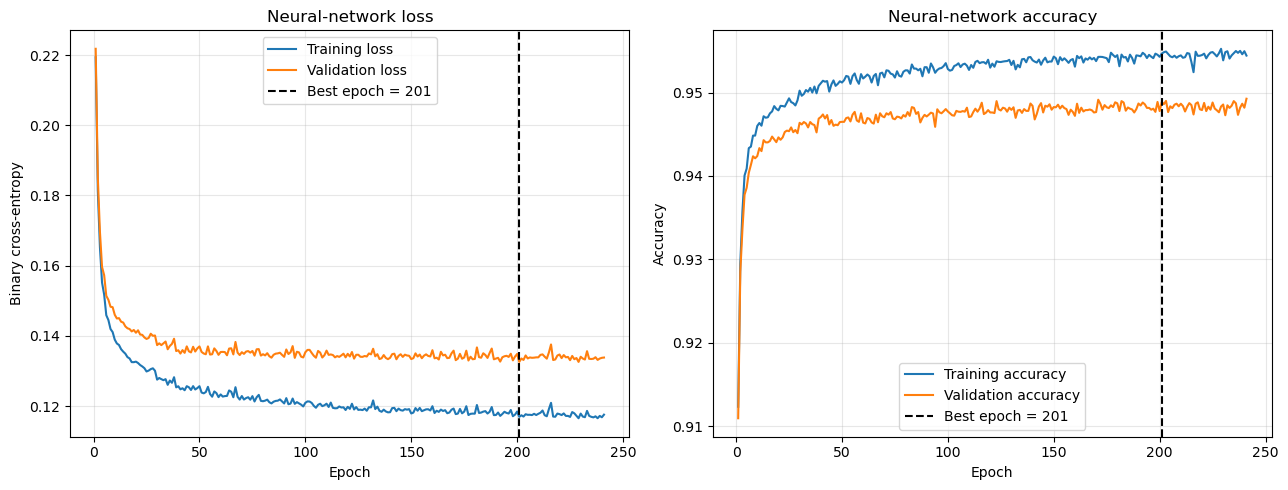

In [39]:

history = numpy_nn.history

epochs_completed = np.arange(
    1,
    len(history["train_loss"]) + 1,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
)

# Loss history.
axes[0].plot(
    epochs_completed,
    history["train_loss"],
    label="Training loss",
)

axes[0].plot(
    epochs_completed,
    history["validation_loss"],
    label="Validation loss",
)

axes[0].axvline(
    numpy_nn.best_epoch,
    color="black",
    linestyle="--",
    label=f"Best epoch = {numpy_nn.best_epoch}",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].set_title("Neural-network loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy history.
axes[1].plot(
    epochs_completed,
    history["train_accuracy"],
    label="Training accuracy",
)

axes[1].plot(
    epochs_completed,
    history["validation_accuracy"],
    label="Validation accuracy",
)

axes[1].axvline(
    numpy_nn.best_epoch,
    color="black",
    linestyle="--",
    label=f"Best epoch = {numpy_nn.best_epoch}",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Neural-network accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


 ### Final test evaluation

 We now evaluate the selected neural-network model on the untouched test
 sample.

In [40]:

nn_test_scores = numpy_nn.predict_proba(X_test_nn)
nn_test_predictions = numpy_nn.predict(
    X_test_nn,
    threshold=0.5,
)

nn_accuracy = accuracy_score(
    y_test,
    nn_test_predictions,
)

nn_balanced_accuracy = balanced_accuracy_score(
    y_test,
    nn_test_predictions,
)

nn_roc_auc = roc_auc_score(
    y_test,
    nn_test_scores,
)

nn_average_precision = average_precision_score(
    y_test,
    nn_test_scores,
)

print("NumPy neural-network test results")
print("---------------------------------")
print(f"Accuracy:          {nn_accuracy:.4f}")
print(f"Balanced accuracy: {nn_balanced_accuracy:.4f}")
print(f"ROC AUC:           {nn_roc_auc:.4f}")
print(f"Average precision: {nn_average_precision:.4f}")

print("\nClassification report:\n")

print(
    classification_report(
        y_test,
        nn_test_predictions,
        target_names=["Background", "Signal"],
        digits=4,
    )
)

NumPy neural-network test results
---------------------------------
Accuracy:          0.9513
Balanced accuracy: 0.8784
ROC AUC:           0.9760
Average precision: 0.8780

Classification report:

              precision    recall  f1-score   support

  Background     0.9670    0.9772    0.9721     36399
      Signal     0.8378    0.7796    0.8076      5499

    accuracy                         0.9513     41898
   macro avg     0.9024    0.8784    0.8899     41898
weighted avg     0.9501    0.9513    0.9505     41898



### Confusion matrix

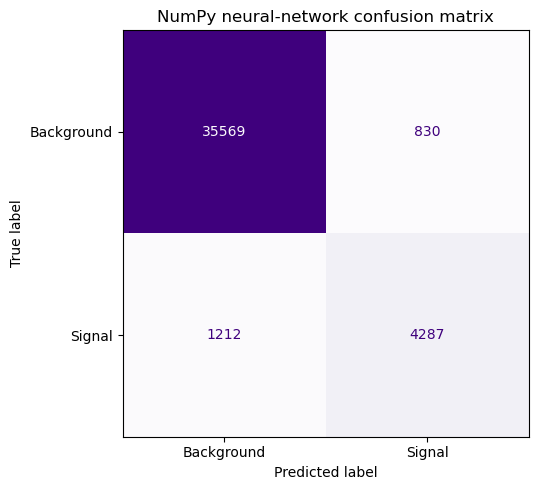

In [41]:

nn_confusion_matrix = confusion_matrix(
    y_test,
    nn_test_predictions,
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=nn_confusion_matrix,
    display_labels=["Background", "Signal"],
).plot(
    ax=ax,
    cmap="Purples",
    values_format="d",
    colorbar=False,
)

ax.set_title("NumPy neural-network confusion matrix")
plt.tight_layout()
plt.show()

### Classifier score distributions

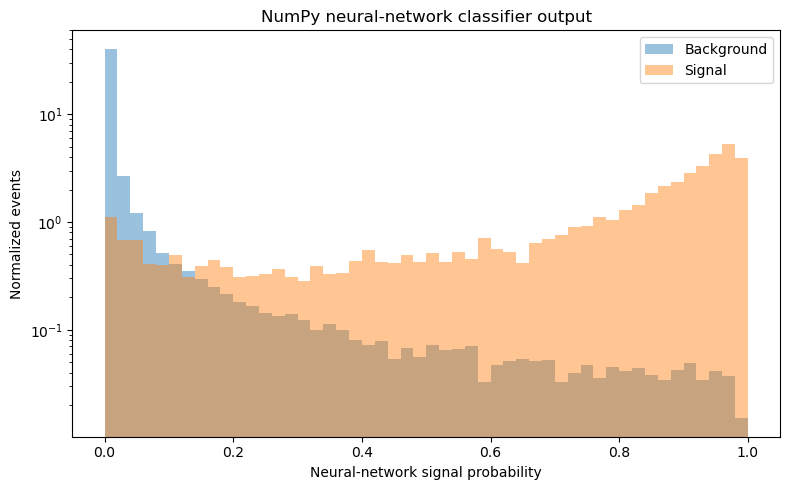

In [42]:

test_labels_array = y_test.to_numpy()

plt.figure(figsize=(8, 5))

plt.hist(
    nn_test_scores[test_labels_array == 0],
    bins=50,
    range=(0, 1),
    density=True,
    histtype="stepfilled",
    alpha=0.45,
    label="Background",
)

plt.hist(
    nn_test_scores[test_labels_array == 1],
    bins=50,
    range=(0, 1),
    density=True,
    histtype="stepfilled",
    alpha=0.45,
    label="Signal",
)

plt.xlabel("Neural-network signal probability")
plt.ylabel("Normalized events")
plt.title("NumPy neural-network classifier output")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

 ## Model comparison

 We compare all three classifiers on exactly the same untouched test events:

 - Logistic regression: linear baseline
 - NumPy neural network: nonlinear dense model
 - XGBoost: nonlinear boosted decision trees

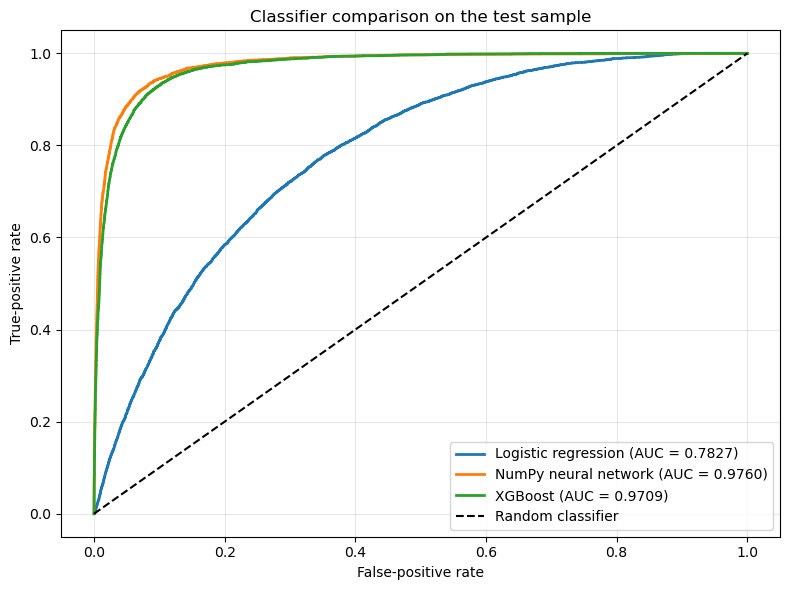

In [43]:

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    y_score,
)

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    baseline_scores,
)

nn_fpr, nn_tpr, _ = roc_curve(
    y_test,
    nn_test_scores,
)

xgb_auc = roc_auc_score(y_test, y_score)
logistic_auc = roc_auc_score(y_test, baseline_scores)
nn_auc = roc_auc_score(y_test, nn_test_scores)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    linewidth=2,
    label=f"Logistic regression (AUC = {logistic_auc:.4f})",
)

plt.plot(
    nn_fpr,
    nn_tpr,
    linewidth=2,
    label=f"NumPy neural network (AUC = {nn_auc:.4f})",
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {xgb_auc:.4f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("Classifier comparison on the test sample")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "NumPy neural network",
        "XGBoost",
    ],
    "ROC AUC": [
        roc_auc_score(y_test, baseline_scores),
        roc_auc_score(y_test, nn_test_scores),
        roc_auc_score(y_test, y_score),
    ],
    "Average precision": [
        average_precision_score(y_test, baseline_scores),
        average_precision_score(y_test, nn_test_scores),
        average_precision_score(y_test, y_score),
    ],
})

model_comparison = model_comparison.sort_values(
    "ROC AUC",
    ascending=False,
).reset_index(drop=True)

display(model_comparison)

,Model,ROC AUC,Average precision
0,NumPy neural network,0.975961,0.877979
1,XGBoost,0.970883,0.850303
2,Logistic regression,0.782741,0.318864


In [45]:

nn_validation_scores = numpy_nn.predict_proba(X_val_nn)

nn_thresholds = np.linspace(0.0, 0.99, 200)
nn_validation_significances = []

y_val_array = y_val.to_numpy()

for threshold in nn_thresholds:
    selected = nn_validation_scores >= threshold

    selected_signal = np.sum(
        selected & (y_val_array == 1)
    )

    selected_background = np.sum(
        selected & (y_val_array == 0)
    )

    denominator = np.sqrt(
        selected_signal + selected_background
    )

    if denominator > 0:
        significance = selected_signal / denominator
    else:
        significance = 0.0

    nn_validation_significances.append(significance)

nn_validation_significances = np.asarray(
    nn_validation_significances
)

best_nn_threshold_index = np.argmax(
    nn_validation_significances
)

optimal_nn_threshold = nn_thresholds[
    best_nn_threshold_index
]

print(
    "Optimal neural-network threshold: "
    f"{optimal_nn_threshold:.3f}"
)

print(
    "Validation significance at selected threshold: "
    f"{nn_validation_significances[best_nn_threshold_index]}")

Optimal neural-network threshold: 0.393
Validation significance at selected threshold: 59.51879184916524


In [46]:

nn_optimal_test_predictions = (
    nn_test_scores >= optimal_nn_threshold
).astype(int)

print(
    classification_report(
        y_test,
        nn_optimal_test_predictions,
        target_names=["Background", "Signal"],
        digits=4,
    )
)

              precision    recall  f1-score   support

  Background     0.9741    0.9701    0.9721     36399
      Signal     0.8075    0.8292    0.8182      5499

    accuracy                         0.9516     41898
   macro avg     0.8908    0.8997    0.8952     41898
weighted avg     0.9522    0.9516    0.9519     41898



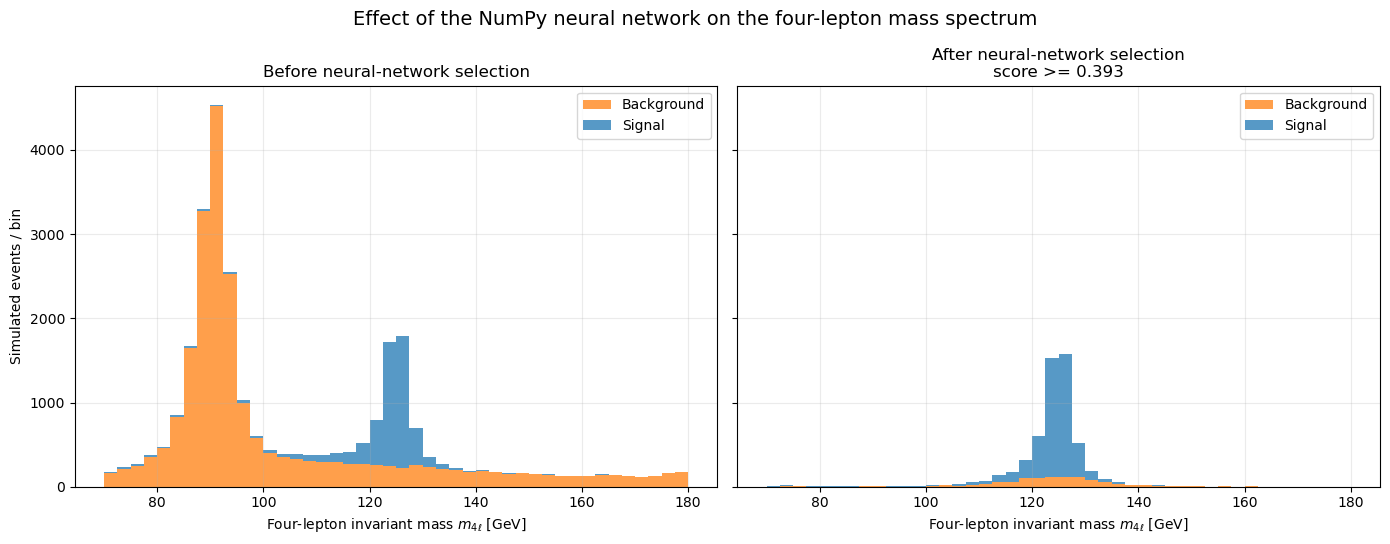

In [47]:
# Recover the invariant mass for the test events.
test_mass = data.loc[X_test.index, "H_mass"].to_numpy()
test_labels = y_test.to_numpy()

nn_selected_test_events = (
    nn_test_scores >= optimal_nn_threshold
)

nn_signal_mass_before = test_mass[
    test_labels == 1
]

nn_background_mass_before = test_mass[
    test_labels == 0
]

nn_signal_mass_after = test_mass[
    (test_labels == 1) & nn_selected_test_events
]

nn_background_mass_after = test_mass[
    (test_labels == 0) & nn_selected_test_events
]

mass_bins = np.linspace(70, 180, 45)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5.5),
    sharex=True,
    sharey=True,
)

axes[0].hist(
    [nn_background_mass_before, nn_signal_mass_before],
    bins=mass_bins,
    stacked=True,
    color=["tab:orange", "tab:blue"],
    alpha=0.75,
    label=["Background", "Signal"],
)

axes[0].set_title("Before neural-network selection")
axes[0].set_xlabel(r"Four-lepton invariant mass $m_{4\ell}$ [GeV]")
axes[0].set_ylabel("Simulated events / bin")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(
    [nn_background_mass_after, nn_signal_mass_after],
    bins=mass_bins,
    stacked=True,
    color=["tab:orange", "tab:blue"],
    alpha=0.75,
    label=["Background", "Signal"],
)

axes[1].set_title(
    "After neural-network selection\n"
    f"score >= {optimal_nn_threshold:.3f}"
)

axes[1].set_xlabel(r"Four-lepton invariant mass $m_{4\ell}$ [GeV]")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle(
    "Effect of the NumPy neural network on the four-lepton mass spectrum",
    fontsize=14,
)

fig.tight_layout()
plt.show()

## Final comparison of logistic regression, NumPy neural network, and XGBoost

 All three classifiers are evaluated using the same validation and test events.

 The validation sample is used to select each model's operating threshold.
 The test sample is used only for the final comparison.

In [48]:
# %%
# Convert labels to one-dimensional NumPy arrays.
y_val_array = y_val.to_numpy(dtype=int)
y_test_array = y_test.to_numpy(dtype=int)

# --------------------------------------------------------------
# Logistic-regression scores
# --------------------------------------------------------------
logistic_validation_scores = baseline_model.predict_proba(
    X_val
)[:, 1]

logistic_test_scores = baseline_model.predict_proba(
    X_test
)[:, 1]

# --------------------------------------------------------------
# NumPy neural-network scores
# --------------------------------------------------------------
nn_validation_scores = numpy_nn.predict_proba(
    X_val_nn
)

nn_test_scores = numpy_nn.predict_proba(
    X_test_nn
)

# --------------------------------------------------------------
# XGBoost scores
# --------------------------------------------------------------
xgb_validation_scores = model.predict_proba(
    X_val
)[:, 1]

xgb_test_scores = model.predict_proba(
    X_test
)[:, 1]

# Store the results in dictionaries to simplify the plotting code.
validation_scores = {
    "Logistic regression": logistic_validation_scores,
    "NumPy neural network": nn_validation_scores,
    "XGBoost": xgb_validation_scores,
}

test_scores = {
    "Logistic regression": logistic_test_scores,
    "NumPy neural network": nn_test_scores,
    "XGBoost": xgb_test_scores,
}

model_colors = {
    "Logistic regression": "tab:green",
    "NumPy neural network": "tab:purple",
    "XGBoost": "tab:blue",
}

 ### Validation-based threshold optimization

 For each model, scan the classifier threshold and maximize:

     S / sqrt(S + B)

 Here, S and B are the selected signal and background event counts in the
 validation sample.

 This is an unweighted educational approximation. A full physics analysis
 should use event weights, luminosity normalization, systematic uncertainties,
 and an appropriate statistical model.

In [49]:

def optimize_classifier_threshold(
    true_labels,
    predicted_scores,
    number_of_thresholds=300,
):
    """
    Select the threshold that maximizes S / sqrt(S + B).

    Parameters
    ----------
    true_labels : array-like
        Binary class labels: zero for background and one for signal.

    predicted_scores : array-like
        Predicted signal probabilities or classifier scores.

    number_of_thresholds : int, default=300
        Number of threshold values to scan.

    Returns
    -------
    results : dict
        Dictionary containing the threshold scan, significance,
        efficiencies, and optimal operating point.
    """
    true_labels = np.asarray(
        true_labels,
        dtype=int,
    )

    predicted_scores = np.asarray(
        predicted_scores,
        dtype=float,
    )

    thresholds = np.linspace(
        0.0,
        0.995,
        number_of_thresholds,
    )

    number_of_signal_events = np.sum(
        true_labels == 1
    )

    number_of_background_events = np.sum(
        true_labels == 0
    )

    significance_values = []
    signal_efficiencies = []
    background_efficiencies = []

    for threshold in thresholds:
        selected_events = (
            predicted_scores >= threshold
        )

        selected_signal = np.sum(
            selected_events
            & (true_labels == 1)
        )

        selected_background = np.sum(
            selected_events
            & (true_labels == 0)
        )

        denominator = np.sqrt(
            selected_signal + selected_background
        )

        if denominator > 0:
            significance = (
                selected_signal / denominator
            )
        else:
            significance = 0.0

        if number_of_signal_events > 0:
            signal_efficiency = (
                selected_signal
                / number_of_signal_events
            )
        else:
            signal_efficiency = 0.0

        if number_of_background_events > 0:
            background_efficiency = (
                selected_background
                / number_of_background_events
            )
        else:
            background_efficiency = 0.0

        significance_values.append(
            significance
        )

        signal_efficiencies.append(
            signal_efficiency
        )

        background_efficiencies.append(
            background_efficiency
        )

    significance_values = np.asarray(
        significance_values
    )

    signal_efficiencies = np.asarray(
        signal_efficiencies
    )

    background_efficiencies = np.asarray(
        background_efficiencies
    )

    optimal_index = int(
        np.argmax(significance_values)
    )

    return {
        "thresholds": thresholds,
        "significance": significance_values,
        "signal_efficiency": signal_efficiencies,
        "background_efficiency": background_efficiencies,
        "background_rejection": (
            1.0 - background_efficiencies
        ),
        "optimal_index": optimal_index,
        "optimal_threshold": float(
            thresholds[optimal_index]
        ),
        "optimal_significance": float(
            significance_values[optimal_index]
        ),
        "optimal_signal_efficiency": float(
            signal_efficiencies[optimal_index]
        ),
        "optimal_background_efficiency": float(
            background_efficiencies[optimal_index]
        ),
    }

In [50]:

optimization_results = {}

for model_name, scores in validation_scores.items():
    optimization_results[model_name] = (
        optimize_classifier_threshold(
            true_labels=y_val_array,
            predicted_scores=scores,
        )
    )

print("Validation-selected operating points")
print("------------------------------------")

for model_name, result in optimization_results.items():
    print(f"\n{model_name}")
    print(
        f"  Optimal threshold:       "
        f"{result['optimal_threshold']:.4f}"
    )
    print(
        f"  Approximate significance:"
        f" {result['optimal_significance']:.4f}"
    )
    print(
        f"  Signal efficiency:       "
        f"{result['optimal_signal_efficiency']:.4f}"
    )
    print(
        f"  Background efficiency:   "
        f"{result['optimal_background_efficiency']:.4f}"
    )
    print(
        f"  Background rejection:    "
        f"{1.0 - result['optimal_background_efficiency']:.4f}"
    )

Validation-selected operating points
------------------------------------

Logistic regression
  Optimal threshold:       0.4559
  Approximate significance: 32.5829
  Signal efficiency:       0.8009
  Background efficiency:   0.3809
  Background rejection:    0.6191

NumPy neural network
  Optimal threshold:       0.3960
  Approximate significance: 59.5586
  Signal efficiency:       0.8087
  Background efficiency:   0.0310
  Background rejection:    0.9690

XGBoost
  Optimal threshold:       0.7687
  Approximate significance: 57.4020
  Signal efficiency:       0.8080
  Background efficiency:   0.0425
  Background rejection:    0.9575


 ### Final metrics on the untouched test sample

 ROC AUC and average precision are threshold-independent.

Accuracy, balanced accuracy (arithmetic mean of sensitivity (true positive rate) and specificity (true negative rate)), signal efficiency, and background rejection are
 calculated using the threshold selected from validation data.

In [51]:

comparison_rows = []
test_predictions = {}

for model_name, scores in test_scores.items():
    threshold = optimization_results[
        model_name
    ]["optimal_threshold"]

    predictions = (
        scores >= threshold
    ).astype(int)

    test_predictions[model_name] = predictions

    signal_mask = (
        y_test_array == 1
    )

    background_mask = (
        y_test_array == 0
    )

    selected_signal = np.sum(
        predictions[signal_mask] == 1
    )

    selected_background = np.sum(
        predictions[background_mask] == 1
    )

    total_signal = np.sum(
        signal_mask
    )

    total_background = np.sum(
        background_mask
    )

    signal_efficiency = (
        selected_signal / total_signal
        if total_signal > 0 else 0.0
    )

    background_efficiency = (
        selected_background / total_background
        if total_background > 0 else 0.0
    )

    selected_significance_denominator = np.sqrt(
        selected_signal + selected_background
    )

    if selected_significance_denominator > 0:
        test_significance = (
            selected_signal
            / selected_significance_denominator
        )
    else:
        test_significance = 0.0

    comparison_rows.append({
        "Model": model_name,
        "Threshold": threshold,
        "ROC AUC": roc_auc_score(
            y_test_array,
            scores,
        ),
        "Average precision": average_precision_score(
            y_test_array,
            scores,
        ),
        "Accuracy": accuracy_score(
            y_test_array,
            predictions,
        ),
        "Balanced accuracy": balanced_accuracy_score(
            y_test_array,
            predictions,
        ),
        "Signal efficiency": signal_efficiency,
        "Background efficiency": background_efficiency,
        "Background rejection": (
            1.0 - background_efficiency
        ),
        "Test S/sqrt(S+B)": test_significance,
        "Selected signal": int(selected_signal),
        "Selected background": int(selected_background),
    })

model_comparison = pd.DataFrame(
    comparison_rows
).sort_values(
    "ROC AUC",
    ascending=False,
).reset_index(drop=True)

display(
    model_comparison.style.format({
        "Threshold": "{:.4f}",
        "ROC AUC": "{:.4f}",
        "Average precision": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced accuracy": "{:.4f}",
        "Signal efficiency": "{:.4f}",
        "Background efficiency": "{:.4f}",
        "Background rejection": "{:.4f}",
        "Test S/sqrt(S+B)": "{:.4f}",
    })
)

,Model,Threshold,ROC AUC,Average precision,Accuracy,Balanced accuracy,Signal efficiency,Background efficiency,Background rejection,Test S/sqrt(S+B),Selected signal,Selected background
0,NumPy neural network,0.3960,0.9760,0.8780,0.9517,0.8992,0.8280,0.0296,0.9704,60.6851,4553,1076
1,XGBoost,0.7687,0.9709,0.8503,0.9397,0.8907,0.8241,0.0428,0.9572,58.0739,4532,1558
2,Logistic regression,0.4559,0.7827,0.3189,0.6366,0.7091,0.8074,0.3892,0.6108,32.5495,4440,14167



 ## Model-performance summary figure

 The four panels show:

 1. ROC curves
 2. Precision-recall curves
 3. Validation significance scan versus threshold
 4. Signal efficiency versus background rejection

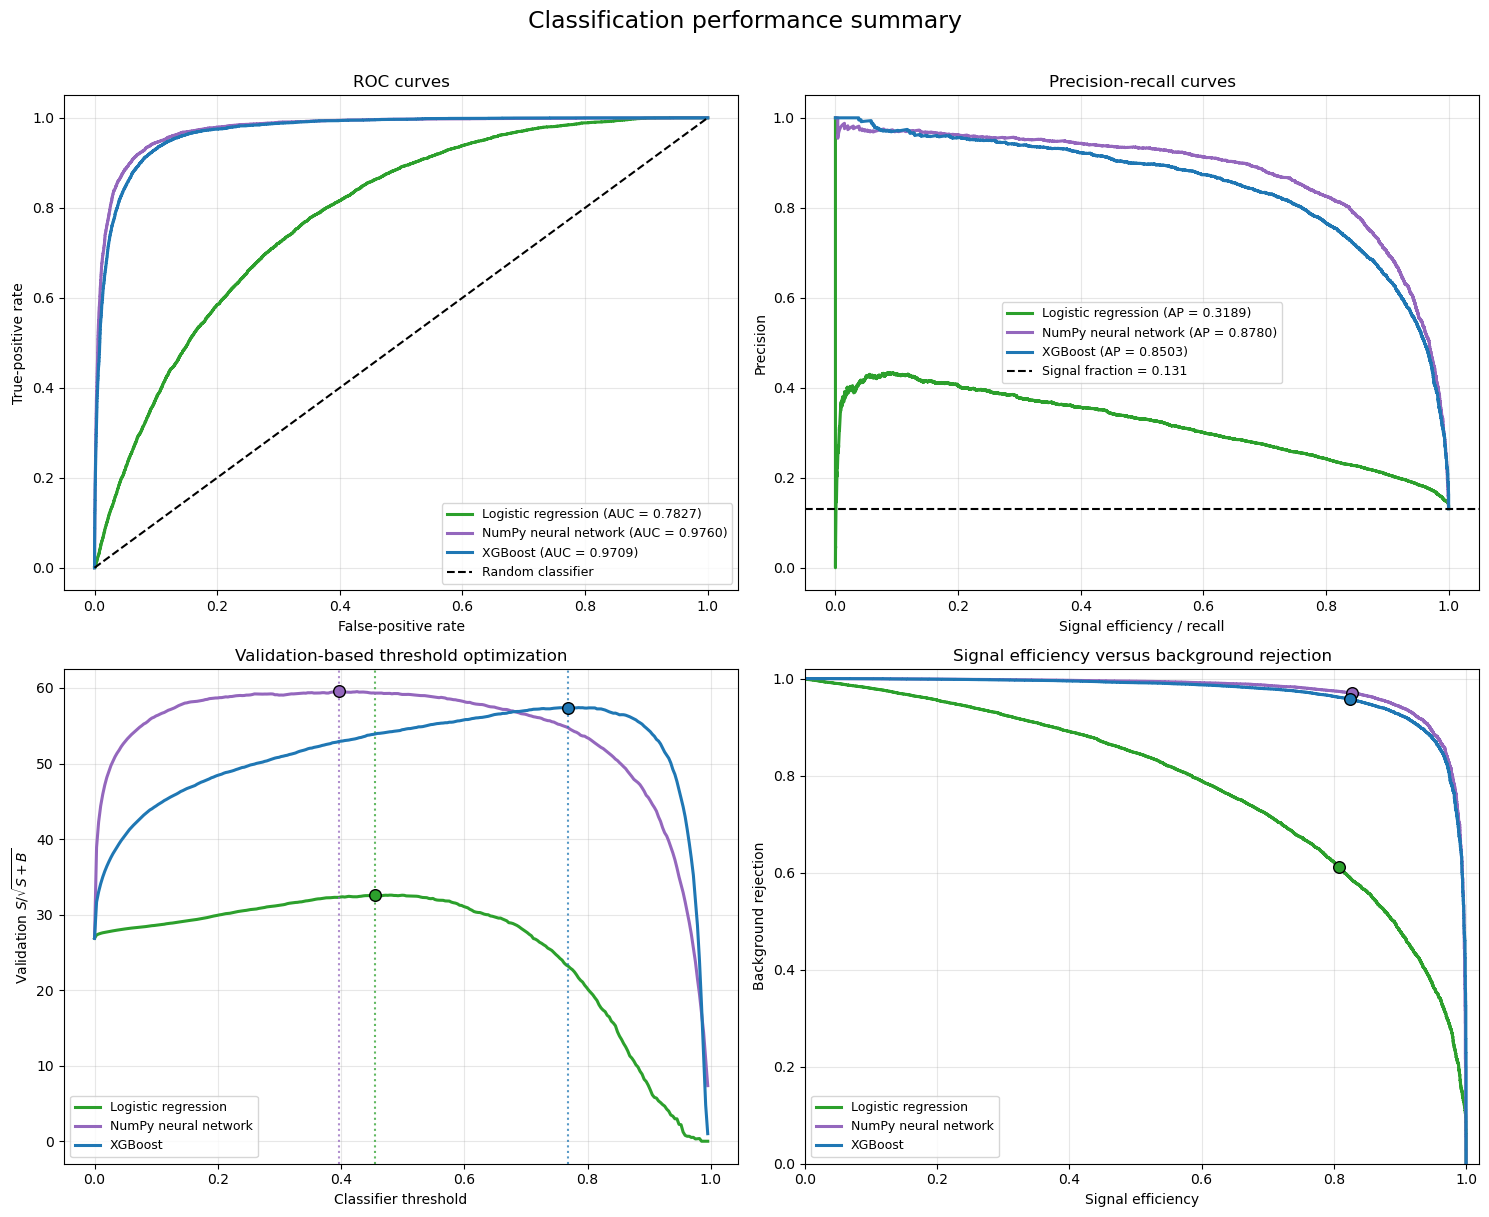

In [52]:

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 12),
)

# ==============================================================
# Panel 1: ROC curves
# ==============================================================
roc_axis = axes[0, 0]

for model_name, scores in test_scores.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_array,
        scores,
    )

    area_under_curve = roc_auc_score(
        y_test_array,
        scores,
    )

    roc_axis.plot(
        false_positive_rate,
        true_positive_rate,
        color=model_colors[model_name],
        linewidth=2.2,
        label=(
            f"{model_name} "
            f"(AUC = {area_under_curve:.4f})"
        ),
    )

roc_axis.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Random classifier",
)

roc_axis.set_xlabel("False-positive rate")
roc_axis.set_ylabel("True-positive rate")
roc_axis.set_title("ROC curves")
roc_axis.grid(alpha=0.3)
roc_axis.legend(fontsize=9)

# ==============================================================
# Panel 2: precision-recall curves
# ==============================================================
pr_axis = axes[0, 1]

for model_name, scores in test_scores.items():
    precision, recall, _ = precision_recall_curve(
        y_test_array,
        scores,
    )

    average_precision = average_precision_score(
        y_test_array,
        scores,
    )

    pr_axis.plot(
        recall,
        precision,
        color=model_colors[model_name],
        linewidth=2.2,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.4f})"
        ),
    )

signal_fraction = np.mean(
    y_test_array
)

pr_axis.axhline(
    signal_fraction,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Signal fraction = {signal_fraction:.3f}"
    ),
)

pr_axis.set_xlabel("Signal efficiency / recall")
pr_axis.set_ylabel("Precision")
pr_axis.set_title("Precision-recall curves")
pr_axis.grid(alpha=0.3)
pr_axis.legend(fontsize=9)

# ==============================================================
# Panel 3: validation significance versus threshold
# ==============================================================
significance_axis = axes[1, 0]

for model_name, result in optimization_results.items():
    significance_axis.plot(
        result["thresholds"],
        result["significance"],
        color=model_colors[model_name],
        linewidth=2.2,
        label=model_name,
    )

    significance_axis.scatter(
        result["optimal_threshold"],
        result["optimal_significance"],
        color=model_colors[model_name],
        edgecolor="black",
        s=70,
        zorder=5,
    )

    significance_axis.axvline(
        result["optimal_threshold"],
        color=model_colors[model_name],
        linestyle=":",
        alpha=0.75,
    )

significance_axis.set_xlabel(
    "Classifier threshold"
)

significance_axis.set_ylabel(
    r"Validation $S/\sqrt{S+B}$"
)

significance_axis.set_title(
    "Validation-based threshold optimization"
)

significance_axis.grid(alpha=0.3)
significance_axis.legend(fontsize=9)

# ==============================================================
# Panel 4: signal efficiency versus background rejection
# ==============================================================
efficiency_axis = axes[1, 1]

for model_name, scores in test_scores.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_array,
        scores,
    )

    background_rejection = (
        1.0 - false_positive_rate
    )

    efficiency_axis.plot(
        true_positive_rate,
        background_rejection,
        color=model_colors[model_name],
        linewidth=2.2,
        label=model_name,
    )

    # Mark the validation-selected threshold on the test curve.
    predictions = test_predictions[
        model_name
    ]

    signal_mask = (
        y_test_array == 1
    )

    background_mask = (
        y_test_array == 0
    )

    signal_efficiency_at_threshold = np.mean(
        predictions[signal_mask] == 1
    )

    background_efficiency_at_threshold = np.mean(
        predictions[background_mask] == 1
    )

    efficiency_axis.scatter(
        signal_efficiency_at_threshold,
        1.0 - background_efficiency_at_threshold,
        color=model_colors[model_name],
        edgecolor="black",
        s=70,
        zorder=5,
    )

efficiency_axis.set_xlabel(
    "Signal efficiency"
)

efficiency_axis.set_ylabel(
    "Background rejection"
)

efficiency_axis.set_title(
    "Signal efficiency versus background rejection"
)

efficiency_axis.set_xlim(0, 1.02)
efficiency_axis.set_ylim(0, 1.02)
efficiency_axis.grid(alpha=0.3)
efficiency_axis.legend(fontsize=9)

fig.suptitle(
    "Classification performance summary",
    fontsize=17,
    y=1.01,
)

fig.tight_layout()
plt.show()

 ## Four-lepton invariant-mass summary

 The invariant mass is retrieved from the original combined DataFrame. This
 also works when H_mass was excluded from the training features with:

     MASS_BLIND = True

 The plots below show raw simulated event counts. They do not include process
 cross sections, luminosity normalization, or detector correction weights.

In [53]:

# Recover the four-lepton mass using the retained DataFrame indices.
test_mass = data.loc[
    X_test.index,
    "H_mass",
].to_numpy(dtype=float)

signal_test_mask = (
    y_test_array == 1
)

background_test_mask = (
    y_test_array == 0
)

signal_mass_before = test_mass[
    signal_test_mask
]

background_mass_before = test_mass[
    background_test_mask
]

# Adjust this range if the ROOT samples cover a different region.
MASS_MINIMUM = 70.0
MASS_MAXIMUM = 180.0
NUMBER_OF_MASS_BINS = 44

mass_bins = np.linspace(
    MASS_MINIMUM,
    MASS_MAXIMUM,
    NUMBER_OF_MASS_BINS + 1,
)

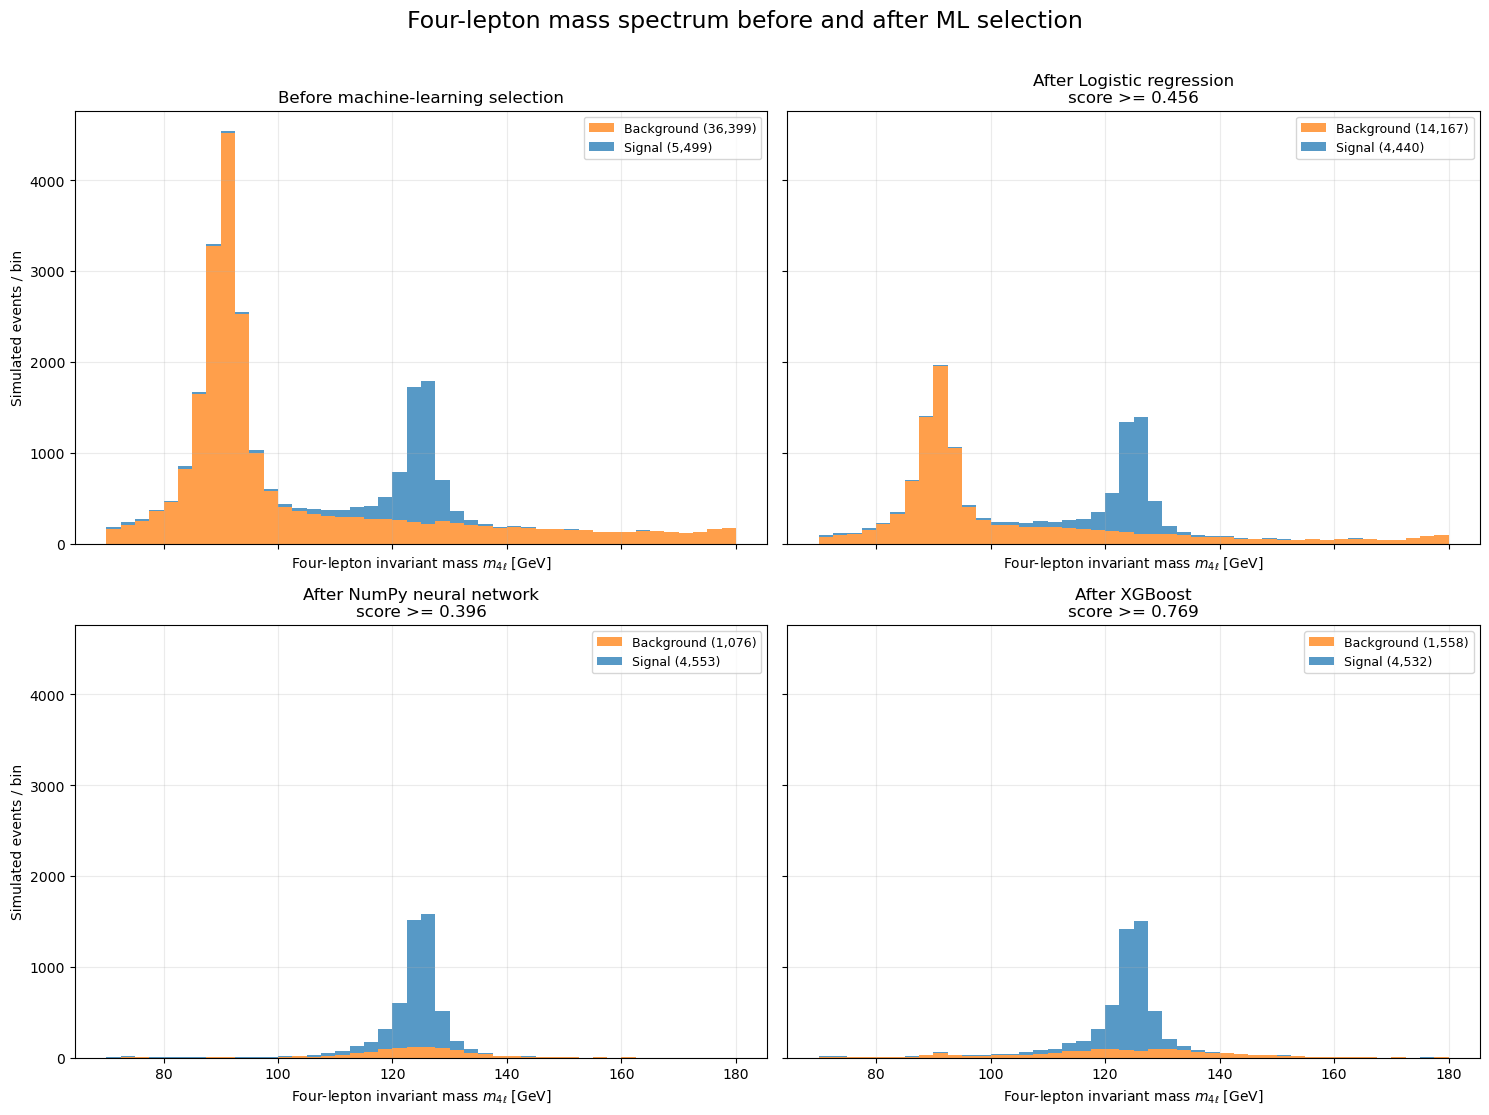

In [54]:

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

# ==============================================================
# Panel 1: before ML selection
# ==============================================================
axes[0].hist(
    [
        background_mass_before,
        signal_mass_before,
    ],
    bins=mass_bins,
    stacked=True,
    color=[
        "tab:orange",
        "tab:blue",
    ],
    alpha=0.75,
    label=[
        f"Background ({len(background_mass_before):,})",
        f"Signal ({len(signal_mass_before):,})",
    ],
)

axes[0].set_title(
    "Before machine-learning selection"
)

axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# ==============================================================
# Panels 2-4: after each model selection
# ==============================================================
plot_order = [
    "Logistic regression",
    "NumPy neural network",
    "XGBoost",
]

for axis, model_name in zip(
    axes[1:],
    plot_order,
):
    selected_events = (
        test_predictions[model_name] == 1
    )

    selected_signal_mass = test_mass[
        signal_test_mask
        & selected_events
    ]

    selected_background_mass = test_mass[
        background_test_mask
        & selected_events
    ]

    threshold = optimization_results[
        model_name
    ]["optimal_threshold"]

    axis.hist(
        [
            selected_background_mass,
            selected_signal_mass,
        ],
        bins=mass_bins,
        stacked=True,
        color=[
            "tab:orange",
            "tab:blue",
        ],
        alpha=0.75,
        label=[
            (
                "Background "
                f"({len(selected_background_mass):,})"
            ),
            (
                "Signal "
                f"({len(selected_signal_mass):,})"
            ),
        ],
    )

    axis.set_title(
        f"After {model_name}\n"
        f"score >= {threshold:.3f}"
    )

    axis.legend(fontsize=9)
    axis.grid(alpha=0.25)

# Shared labels.
for axis in axes:
    axis.set_xlabel(
        r"Four-lepton invariant mass $m_{4\ell}$ [GeV]"
    )

axes[0].set_ylabel(
    "Simulated events / bin"
)

axes[2].set_ylabel(
    "Simulated events / bin"
)

fig.suptitle(
    "Four-lepton mass spectrum before and after ML selection",
    fontsize=17,
    y=1.01,
)

fig.tight_layout()
plt.show()

 ## Comparison of the selected operating points

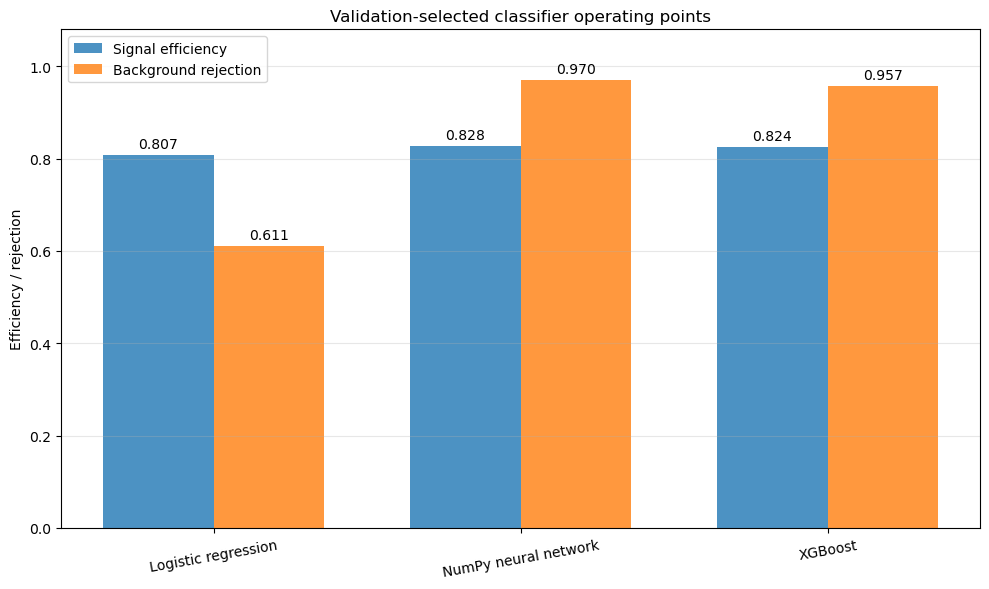

In [55]:
# %%
operating_point_table = model_comparison.set_index(
    "Model"
).loc[
    plot_order
]

x_positions = np.arange(
    len(plot_order)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=(10, 6)
)

signal_bars = ax.bar(
    x_positions - bar_width / 2,
    operating_point_table[
        "Signal efficiency"
    ],
    width=bar_width,
    color="tab:blue",
    alpha=0.8,
    label="Signal efficiency",
)

background_bars = ax.bar(
    x_positions + bar_width / 2,
    operating_point_table[
        "Background rejection"
    ],
    width=bar_width,
    color="tab:orange",
    alpha=0.8,
    label="Background rejection",
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    plot_order,
    rotation=10,
)

ax.set_ylabel(
    "Efficiency / rejection"
)

ax.set_ylim(
    0.0,
    1.08,
)

ax.set_title(
    "Validation-selected classifier operating points"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

ax.bar_label(
    signal_bars,
    fmt="%.3f",
    padding=3,
)

ax.bar_label(
    background_bars,
    fmt="%.3f",
    padding=3,
)

fig.tight_layout()
plt.show()

### Final words

1. Logistic regression provides a linear baseline, while the NumPy neural network and XGBoost can learn nonlinear relationships between the reconstructed event features.

2. The thresholds were selected exclusively with validation events and applied to an untouched test sample.

3. The invariant-mass plots show how each classifier trades signal efficiency for background rejection and how this changes the visibility of the simulated Higgs signal near 125 GeV.

4. Because the plots use unweighted simulated events, they demonstrate classification performance rather than an expected experimental event yield or discovery significance.